# Lesson149 · Weakest RelBench tasks: stress-test the thesis

Teacher reference · Tier B: full real RelBench query evidence. PROVIDED → three live TODO/CHECK tasks → catalog export → written EXIT. Default is a portable CPU analysis. Separate complete training gates use their pinned FE or GPU runtimes; do not mix their dependencies.

In [1]:
# @colab-bootstrap: portable CPU audit; no repository checkout required.
import importlib.util,subprocess,sys
missing=[p for p in ['numpy','pandas','IPython'] if importlib.util.find_spec(p) is None]
if missing:subprocess.check_call([sys.executable,'-m','pip','install',*missing])
import base64,gzip,hashlib,io,json,math
from pathlib import Path
import numpy as np,pandas as pd
from IPython.display import display
def rejects(fn):
 try: fn()
 except ValueError: return
 raise AssertionError('Invalid evidence was accepted')

**The question:** where does learned relational prediction lose to a strong feature-engineered baseline—and what would change your mind about the explanation?

[Lesson 148](https://avistian.github.io/relational/lessons/0148-ablation-discipline.html) asked which component earns a gain. That leaves a harder question: which tasks fail to produce a gain at all? The mission is to demonstrate useful relational learning, so a weakness catalog is part of the evidence for the thesis. A catalog records counterexamples instead of hiding them behind a benchmark average.

**Your tangible win:** produce a provenance-aware task ranking and a one-page weakness profile. The core reading and worked example are a short session; the full-data lab and reproduction appendix are a separate session.

**Read first:** [RelBench v1 §6, Figure 3 and Appendix C.2](https://arxiv.org/html/2407.20060v1#S6). Read the output-head qualification before comparing its regression results with Table 7. [Released user-study code](https://github.com/snap-stanford/relbench-user-study/tree/445bb7a3b1230f49f8e5890ae81754d3e365680f) is the primary source for the manual feature-engineering comparator.



## 2 · Make “weak” mean something precise

> **In plain terms.** A model can have a respectable score and still lose to a cheaper or better-informed baseline. Weakness is comparative. First specify which two complete procedures you are comparing.

**Feature engineering (FE)** means computing task-specific input columns from the database, such as a driver's recent standings. A tree model then learns from those columns. **RDL** here means a learned row encoder and graph neural network that combine relational context to predict a query target. Both can use information from multiple tables. This is not a comparison of “relational information” against “no relational information.”

A **query** is an entity together with a prediction cutoff. The same driver at two dates is two different queries. A fair error comparison aligns both predictions with the same `(driver_id, cutoff)` and target, rejecting missing or duplicate keys.

**AUROC** measures how often a positive example receives a higher score than a negative example, with half credit for ties. Higher is better. **MAE**, mean absolute error, averages the absolute distance between a prediction and its target. Lower is better. MAE carries the target's units.

**Worked example.** Suppose RDL has MAE 4.2 and FE has MAE 3.9. RDL loses by 0.3. For an oriented advantage that is always positive when RDL wins, use `FE − RDL` for MAE: −0.3. If AUROCs are 0.72 and 0.75, use `RDL − FE`: −0.03, or −3 percentage points. Never sort −0.3 position units beside −3 AUROC points as if their magnitudes were comparable.

**The signed advantage:** `A = RDL − FE` for AUROC; `A = FE − RDL` for MAE. The weakest point estimate sorts first, with the smallest A. Our slice plots later use a **loss penalty** `D = |y − GNN| − |y − FE|`: positive D means the GNN loses. Thus for MAE, `A = −mean(D)`. Each plot labels its sign.

<figure class="weakness-figure" tabindex="0">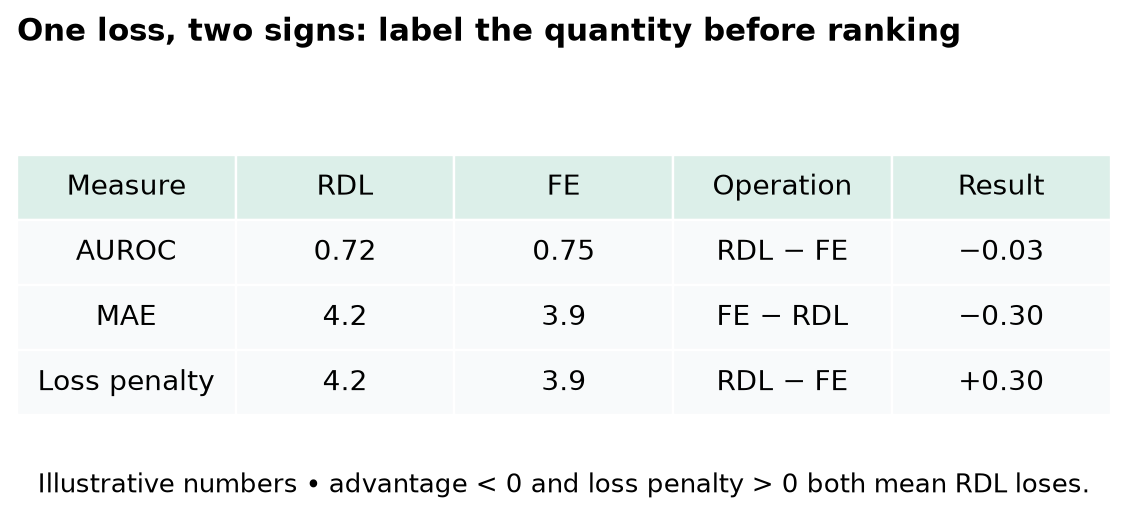<figcaption>Illustrative sign contract: metric advantage is positive when RDL wins; the loss penalty uses the opposite sign. Scroll for detail on a narrow screen.</figcaption></figure>

**Normalization changes the question.** Figure 3 divides each regression score by that task's RDL score. Its RDL bars equal 1. A normalized advantage of −0.35 means FE MAE is about 0.65 times RDL MAE. It does not mean a 0.35-unit error on the original target. Relative gaps can support an ordering under that normalization; they are not universal measures of business harm.



### TODO · oriented_gap

**Goal:** Compute a signed advantage with a single meaning across metrics. Reject invalid units and nonfinite scores.

**Why:** an invalid ranking can manufacture a counterexample. Your function is called on the real evidence below.

In [2]:
def oriented_gap(rdl, fe, metric):
    """AUROC inputs are fractions; MAE stays in its original target units."""
    if metric not in ('AUROC','MAE'): raise ValueError('Unknown metric')
    if not all(isinstance(v,(int,float)) and math.isfinite(v) for v in [rdl,fe]):
        raise ValueError('Finite scores required')
    if metric=='AUROC' and not all(0<=v<=1 for v in [rdl,fe]):
        raise ValueError('AUROC must be a fraction')
    if metric=='MAE' and min(rdl,fe)<0: raise ValueError('Negative loss')
    return rdl-fe if metric=='AUROC' else fe-rdl

In [3]:
def check_gap(fn):
 assert math.isclose(fn(.72,.75,'AUROC'),-.03)
 assert math.isclose(fn(4.,3.,'MAE'),-1.)
 rejects(lambda:fn(float('nan'),3,'MAE'))
 rejects(lambda:fn(4,3,'accuracy'))
 rejects(lambda:fn(72,75,'AUROC'))
 rejects(lambda:fn(-1,3,'MAE'))
check_gap(oriented_gap)
print("PASS: oriented_gap")

PASS: oriented_gap


## 3 · The published weakness catalog

Before revealing the catalog, predict whether a basic GNN's F1 score is interchangeable with Figure 3's regression bar.

Predict: can Table7 basic GNN replace the Figure3 regression comparator? No. Figure3 uses a GNN+LightGBM head.

The answer is consequential. **Figure 3 uses GNN features with a LightGBM output head for regression.** Table 7 reports basic RDL. An output head is the final mapping from the learned representation to the target. A tree head changes that mapping and the complete training procedure. Appendix C.2 investigates this distinction; it does not prove every regression failure has the same cause.

### Classification · AUROC points

| Task (figure label) | RDL | FE | RDL advantage |
|---|---|---|---|
| rel-f1/driver-top3 | 78.3 | 82.4 | -4.1 |
| rel-stack/user-engagement | 90.2 | 90.3 | -0.1 |
| rel-hm/user-churn | 69.4 | 69.0 | +0.4 |
| rel-amazon/item-churn | 83.0 | 81.8 | +1.2 |
| rel-stack/user-badge | 88.2 | 86.1 | +2.0 |
| rel-f1/driver-dnf | 72.0 | 69.8 | +2.2 |
| rel-amazon/user-churn | 70.5 | 67.6 | +2.9 |
| rel-trial/study-outcome | 66.5 | 58.9 | +7.6 |

### Regression · normalized MAE

| Task (figure label) | RDL | FE | RDL advantage |
|---|---|---|---|
| rel-hm/item-sales | 1.00 | 0.65 | -0.35 |
| rel-amazon/item-ltv | 1.00 | 0.89 | -0.11 |
| rel-trial/study-adverse | 1.00 | 0.95 | -0.05 |
| rel-amazon/user-ltv | 1.00 | 0.99 | -0.01 |
| rel-f1/driver-position | 1.00 | 1.01 | +0.01 |
| rel-trial/site-success | 1.00 | 1.02 | +0.02 |
| rel-stack/user-votes | 1.00 | 1.03 | +0.03 |



The catalog covers the **15 tasks in the user study**, not all 30 tasks in the initial benchmark. We extracted mean bar endpoints from the paper's SVG, calibrated against its printed ticks, and checked task labels against the rendered figure. Classification scores are displayed to 0.1 AUROC point; regression ratios to 0.01. These are **PLOT_DERIVED** values, not recovered original logs. Geometric precision does not recover experimental certainty. We have not digitized the error bars, so this is a ranking of mean bars, not a significance ranking.

The ranking identifies **rel-f1/driver-top3** as the largest negative classification point gap and **rel-hm/item-sales** as the largest negative normalized regression gap. Close positions and near-zero gaps should not be read as decisive. The SVG labels one regression task `user-votes`, whereas Table 7 names `post-votes`; we retain the figure label and mark the cross-table task identity unresolved. For example, user-engagement has a tiny negative mean gap; the paper's “matches or outperforms” statement is not a count of strictly positive mean differences.

<figure class="weakness-figure" tabindex="0">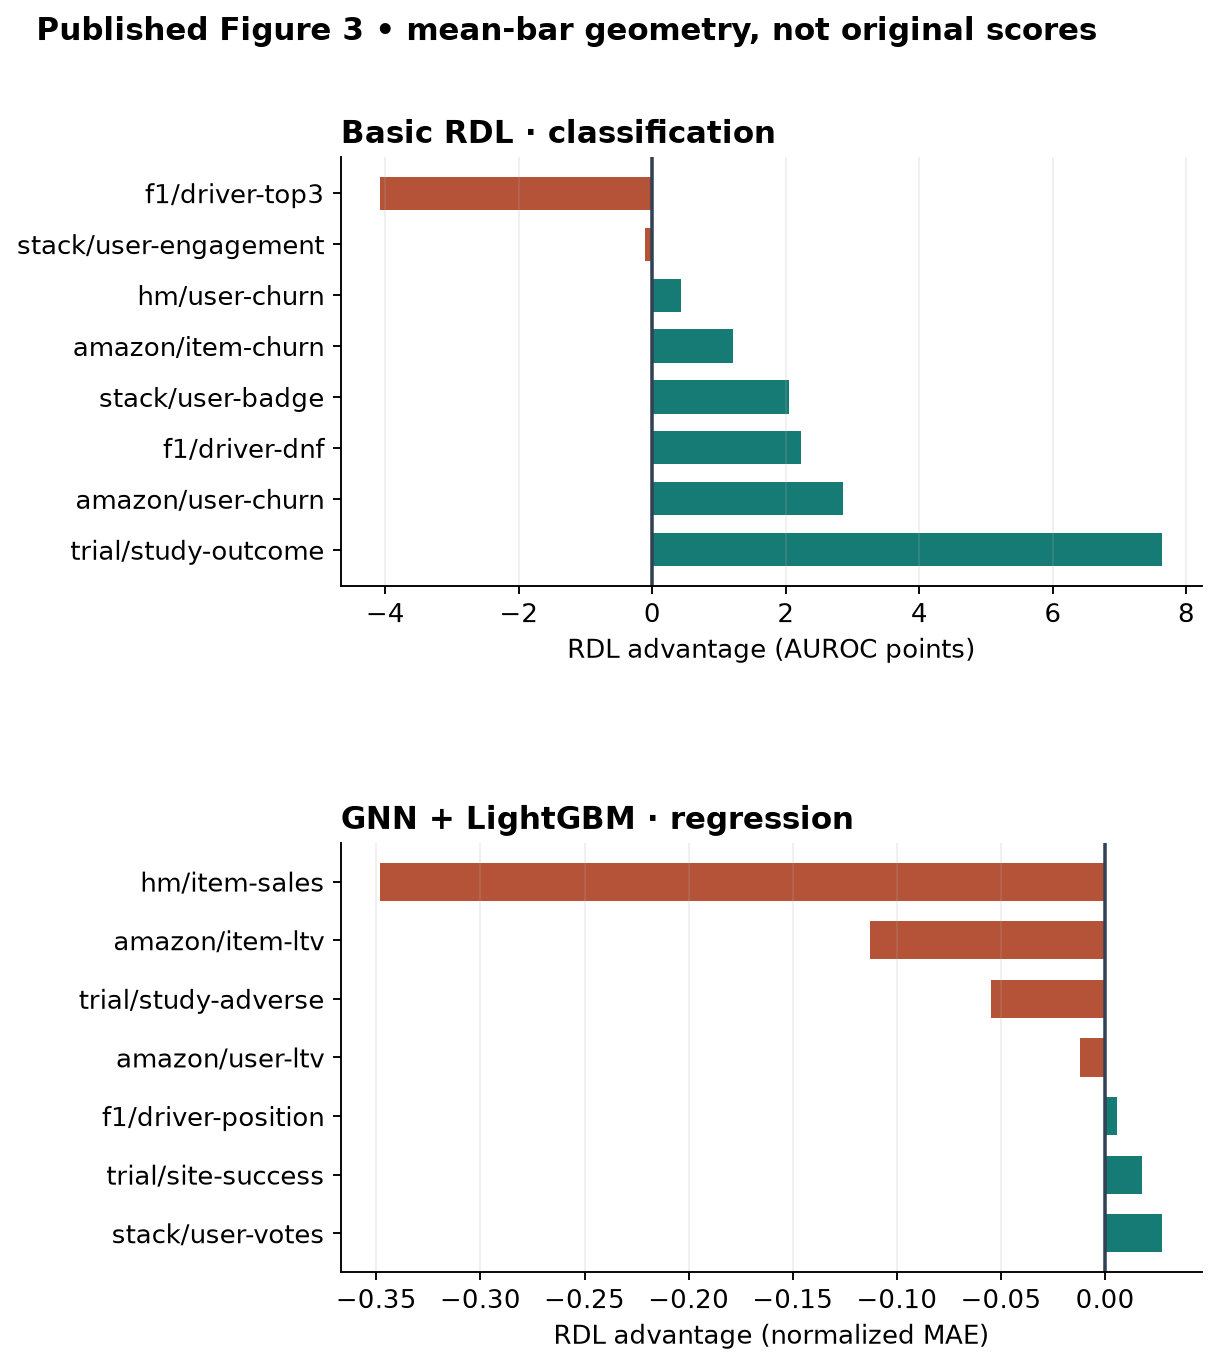<figcaption>Published Figure3 mean-bar extraction. Panels have different units and regression uses a boosted head; no original error bars or significance ranking recovered. Scroll for detail on a narrow screen.</figcaption></figure>

### Change the evidence contract

Static ranking: driver-top3 has the largest negative classification point gap; item-sales has the largest negative normalized regression point gap. The complete tables remain above.

Predict before switching panels: can the F1 replay be inserted into the Figure 3 regression ranking? The widget keeps these evidence families separate. It also lets you change how large a disadvantage must be before it is flagged. That threshold is a declared decision rule, not a statistical test. A task falling below the threshold remains in the catalog.



### TODO · rank_catalog

**Goal:** Rank the weakest compatible evidence first. Reject duplicate tasks, missing measurements and mismatched provenance, split, variant or metric.

**Why:** an invalid ranking can manufacture a counterexample. Your function is called on the real evidence below.

In [4]:
def rank_catalog(rows):
    """Rank weakest first inside one metric/variant/split/evidence family."""
    if not rows: return []
    fields=('metric','variant','split','source')
    contract=tuple(rows[0][f] for f in fields)
    out=[];seen=set()
    for row in rows:
        if tuple(row[f] for f in fields)!=contract: raise ValueError('Incomparable evidence')
        if row['task'] in seen: raise ValueError('Duplicate task')
        if row['status'] not in ('EXACT','PLOT_DERIVED'): raise ValueError('Unavailable evidence')
        seen.add(row['task'])
        out.append(dict(row,gap=oriented_gap(row['rdl'],row['fe'],row['metric'])))
    return sorted(out,key=lambda r:(r['gap'],r['task']))

In [5]:
def check_rank(fn):
 rows=[dict(task='b',rdl=.75,fe=.8,metric='AUROC',variant='basic',split='test',source='published',status='EXACT'),dict(task='a',rdl=.7,fe=.8,metric='AUROC',variant='basic',split='test',source='published',status='EXACT')]
 assert [r['task'] for r in fn(rows)]==['a','b']
 rejects(lambda:fn(rows+[dict(rows[0],task='c',metric='MAE')]))
 rejects(lambda:fn(rows+[dict(rows[0],task='c',variant='boosted')]))
 rejects(lambda:fn(rows+[dict(rows[0],task='c',source='local')]))
 rejects(lambda:fn(rows+[dict(rows[0],task='c',split='val')]))
 rejects(lambda:fn(rows+[dict(rows[0],task='c',status='MISSING',rdl=None)]))
 rejects(lambda:fn(rows+[rows[0]]))
 if fn(rows)[0].get('gap') is None: raise AssertionError('Ranking must show its gap')
check_rank(rank_catalog)
print("PASS: rank_catalog")

PASS: rank_catalog


## 4 · A complete, affordable case study

The worst published regression point is H&M item-sales. Our fresh training case is **F1 driver-position**, selected in advance for a feasible full two-pipeline replay. We profile the published worst task through source evidence and a falsifiable hypothesis; we profile F1 with fresh predictions. We do not relabel the affordable case as the global worst.

**Published worst-task profile: H&M item-sales.** The task asks how many times an article will be purchased in the next seven days. Its large negative normalized gap is evidence about the Figure 3 boosted pipeline. A plausible explanation is that recent sales levels and temporal patterns are easier for the engineered features to expose. That is a hypothesis: it needs a cutoff-safe feature audit and a controlled intervention, such as adding the same legal sales summaries to the graph pipeline while keeping queries and selection fixed. If that does not reduce the validation gap, the proposed missing-summary explanation loses support. We have not run that intervention or retrained H&M here.

**Fresh F1 protocol.** We use the complete released dataset: 7,453 training, 499 validation and 760 test queries. Each label is the driver's mean finishing position in the next 60 days, conditional on participating. Five fresh GNN fits each train ten complete epochs. The graph model uses typed row encoders, relative time, two 128-channel GraphSAGE layers, sum aggregation, fanout 128/64, batch 512 and Adam with learning rate 0.005. The first strict minimum-validation checkpoint is selected, and predictions are clipped to training-label percentiles as in the released pipeline.

**The competing FE procedure** freshly computes the released SQL columns, fits preprocessing on training rows and performs ten LightGBM trials per seed, five seeds total, followed by selected train-only refits. Each trial has a 2,000-round ceiling and 50-round early stopping. Test results never choose a trial. The notebook exposes the SQL, model, optimizer and training loops in its reproduction appendix.

**What stays fixed:** task archives, query identities, splits and evaluation target. **What differs:** representation, preprocessing scope, learning procedure, search budget, and temporal details of the available inputs. This estimates a difference between complete released procedures. It does not isolate the causal effect of message passing.

> **Scope check.** The snapshot caps the database at 2010-01-01. GNN preprocessing uses that released snapshot, while FE category mappings fit training rows. Some FE schedule features reference future scheduled dates with unknown publication times. Static attributes lack historical mutation/arrival records. Event-time checks do not establish what was truly available in production. Original archive/run identity remains **NOT_ESTABLISHED**.

| Seed | GNN validation | FE validation | GNN test | FE test |
|---|---|---|---|---|
| 0 | 3.159966 | 2.744086 | 4.355555 | 3.921045 |
| 1 | 3.173181 | 2.816721 | 3.989141 | 4.042601 |
| 2 | 3.207023 | 2.773399 | 4.398051 | 3.852457 |
| 3 | 3.149367 | 2.791052 | 3.884890 | 3.980605 |
| 4 | 3.173453 | 2.761390 | 3.987721 | 3.947876 |

**VAL mean ± sample seed SD:** GNN 3.172598 ± 0.021711; FE 2.777330 ± 0.027905 MAE.

**TEST mean ± sample seed SD:** GNN 4.123071 ± 0.235929; FE 3.948917 ± 0.070469 MAE.

Test GNN loss penalty **+0.174155**, descriptive driver-cluster 95% interval **[-0.085850, 0.449621]**. The interval crosses zero; neither superiority nor equivalence is established. Five paired run labels do not imply common random numbers across model families.


<figure class="weakness-figure" tabindex="0">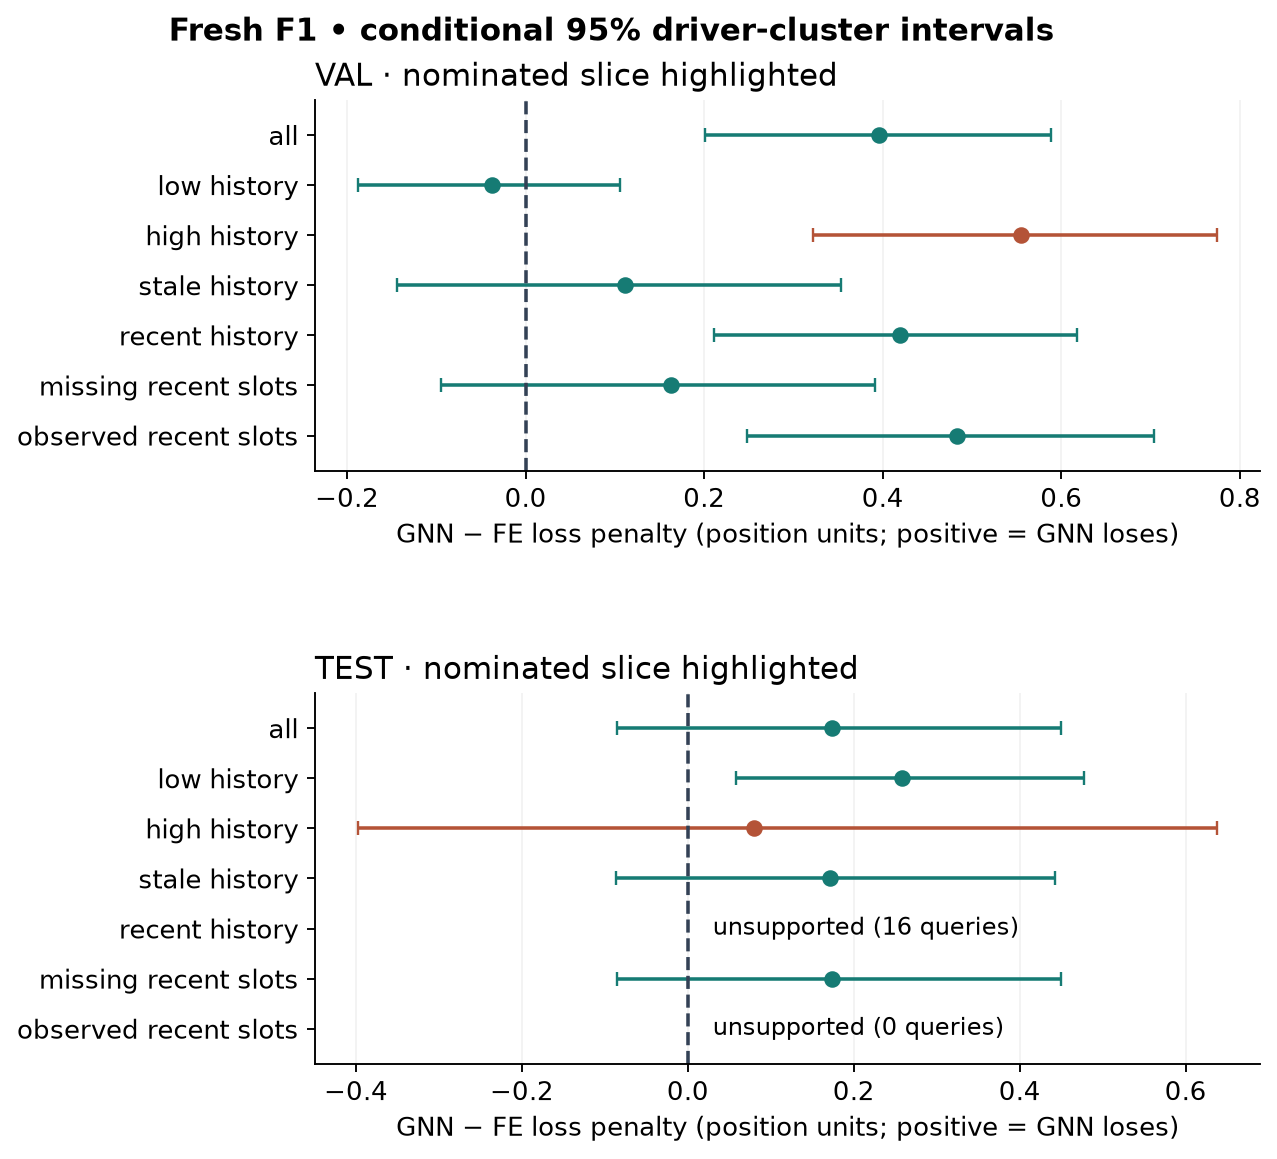<figcaption>Fresh F1 per-query mean losses across five fits. Intervals resample whole drivers and condition on the fitted models and split; highlighted slice was nominated using validation. Scroll for detail on a narrow screen.</figcaption></figure>

The GNN paper target is validation 3.193/test 4.022 MAE (Table 7). A predeclared ±0.2 MAE descriptive tolerance records closeness; it is not a statistical equivalence test. The historical FE scalar and Figure 3 training randomness are not recovered. Full selected released-pipeline execution is a narrower claim than exact historical result reproduction.



## 5 · Test the explanation, not just the ranking

A **slice** is a subset of queries defined by a feature available at prediction time. We predeclare six slices in three complementary pairs: low/high history; stale/recent history; missing/observed recent race-slot features. History is the number of strictly earlier result rows. Low history uses the training median, 22. Stale means more than 180 days since a previous result. Missing means at least half of the 24 recent-slot columns are absent.

Cold start means having no prior observed history. It is not synonymous with our low-history slice, which includes drivers with up to 22 records. A bad low-history score alone would not establish a cold-start mechanism.

**The support rule:** require at least 30 queries and 10 distinct drivers. Support is a floor for interpreting a slice, not a guarantee of precision. Nominate the largest positive mean validation loss penalty among supported slices; ties use the slice name. If none loses, nominate none. Freeze that decision before examining test slice results. All slices stay in the report, including empty ones.

| Split | Slice | Queries/drivers | GNN loss penalty | 95% conditional interval |
|---|---|---|---|---|
| val | all | 499/47 | +0.3953 | [+0.2007, +0.5890] |
| val | low_history | 134/28 | -0.0382 | [-0.1878, +0.1057] |
| val | high_history | 365/35 | +0.5544 | [+0.3220, +0.7748] |
| val | stale_history | 39/32 | +0.1108 | [-0.1436, +0.3532] |
| val | recent_history | 460/41 | +0.4194 | [+0.2115, +0.6178] |
| val | missing_recent_slots | 137/47 | +0.1625 | [-0.0947, +0.3918] |
| val | observed_recent_slots | 362/41 | +0.4834 | [+0.2478, +0.7038] |
| test | all | 760/56 | +0.1742 | [-0.0859, +0.4496] |
| test | low_history | 401/37 | +0.2585 | [+0.0574, +0.4778] |
| test | high_history | 359/19 | +0.0799 | [-0.3977, +0.6382] |
| test | stale_history | 744/56 | +0.1712 | [-0.0861, +0.4431] |
| test | recent_history | 16/16 | +0.3096 | UNSUPPORTED |
| test | missing_recent_slots | 760/56 | +0.1742 | [-0.0859, +0.4496] |
| test | observed_recent_slots | 0/0 | — | UNSUPPORTED |

**Frozen nomination: high_history.** Its validation penalty is +0.5544; test +0.0799 with an interval crossing zero. Low history is not the largest observed validation weakness. This undermines the simple cold-start story for this comparison without establishing the actual cause.


**Why resample drivers?** One driver's errors at several dates are related. A driver-cluster bootstrap repeatedly samples whole drivers with replacement, keeps all their queries and recomputes the query-weighted mean. Our intervals use 2,000 draws after averaging each query's losses over the five fits. They describe uncertainty conditional on these fitted models and this split. Shared races and time shocks remain; these are neither cross-database intervals nor full training-uncertainty intervals.

An interval crossing zero permits both signs under this descriptive resampling. It does not prove equality. A narrow seed SD only says these five fits were similar; it does not eliminate sampling uncertainty. The test population has appeared in earlier lessons, so the profile is exploratory rather than a pristine confirmatory experiment.

### Three hypotheses with different falsifiers

| Hypothesis | Diagnostic evidence | Intervention that could refute it |
|---|---|---|
| Little usable history harms RDL | Validation penalty concentrated in genuinely empty/short histories | Add matched legal history summaries; no improvement weakens that explanation |
| Relational context has little predictive signal | A controlled no-message model retains performance | Compare full and no-message models under fixed inputs, capacity caveats and selection |
| Explicit rules or summaries favor FE | Audited engineered feature predicts residual errors | Supply that feature to both pipelines; persistence of the gap weakens missing-feature attribution |

These are proposed tests. A performance gap alone establishes none of their causes. Use [L148's ablation discipline](https://avistian.github.io/relational/lessons/0148-ablation-discipline.html) to turn a story into an intervention.



### TODO · nominate_slice

**Goal:** Nominate the largest supported positive validation loss penalty. Report all slices and return no nomination when no supported slice loses.

**Why:** an invalid ranking can manufacture a counterexample. Your function is called on the real evidence below.

In [6]:
def nominate_slice(delta, entities, masks, split='val', min_rows=30, min_entities=10):
    """Choose largest positive supported mean on validation; report unsupported slices."""
    if split!='val':raise ValueError('Only validation may nominate a slice')
    d=np.asarray(delta,dtype=float);e=np.asarray(entities)
    if d.ndim!=1 or e.shape!=d.shape or not np.isfinite(d).all():raise ValueError('Invalid aligned losses')
    rows={}
    for name,mask in sorted(masks.items()):
        m=np.asarray(mask)
        if m.dtype!=bool or m.shape!=d.shape:raise ValueError('Require one boolean per query')
        n=int(m.sum());groups=len(np.unique(e[m]));supported=n>=min_rows and groups>=min_entities
        rows[name]=dict(rows=n,entities=groups,supported=supported,mean=float(d[m].mean()) if n else None)
    eligible=[name for name,r in rows.items() if r['supported'] and r['mean']>0]
    selected=min(eligible,key=lambda name:(-rows[name]['mean'],name)) if eligible else None
    return dict(selected=selected,slices=rows,split=split,min_rows=min_rows,min_entities=min_entities)

In [7]:
def check_nominate(fn):
    d=np.array([4.,4.,-2.,-2.]);ids=np.array([1,2,3,4])
    masks={'a':np.array([1,1,0,0],bool),'b':np.ones(4,bool),'tiny':np.array([1,0,0,0],bool)}
    r=fn(d,ids,masks,min_rows=2,min_entities=2)
    assert r['selected']=='a' and not r['slices']['tiny']['supported']
    assert fn(-np.ones(4),ids,{'all':np.ones(4,bool)},min_rows=2,min_entities=2)['selected'] is None
    rejects(lambda:fn(d,ids,masks,split='test'))
    assert fn(d,np.ones(4),masks,min_rows=2,min_entities=2)['selected'] is None
    rejects(lambda:fn(d,ids,{'bad':np.ones(3,bool)}))
check_nominate(nominate_slice)
print("PASS: nominate_slice")

PASS: nominate_slice


## 6 · Lab: export the weakness catalog

[Student notebook](https://avistian.github.io/relational/labs/0149-weakest-relbench-tasks.ipynb) · [Prepared notebook](https://avistian.github.io/relational/labs/html/0149-weakest-relbench-tasks.html) · [Reference](https://avistian.github.io/relational/reference/weakest-relbench-tasks.html) · [Reproduction ledger](https://avistian.github.io/relational/labs/l149-reproduction.md).

Implement three live functions: orient metric gaps without mixing units; rank only compatible evidence; nominate a supported validation weakness. Your code processes the published catalog and every primary held-out prediction. The independent checks reject flipped signs, missing scores, mixed model variants, mixed splits and unsupported slices. The default notebook reanalyzes saved author evidence; the complete training lanes are separately gated and require their pinned runtimes.

**EXIT · 150–250 words.** Name one published weakness and the fresh F1 result. State the metric, comparator and evidence source for each. Explain whether the nominated F1 slice supports your original prediction. Propose one affordable intervention, its falsifier and one claim the current evidence cannot establish. Attach the exported catalog and report. Author execution does not establish learner mastery: **PENDING_WRITTEN_DEFENSE**.

Write a weakness profile with comparator, metric, provenance, uncertainty, intervention and falsifier. Ask the teaching agent to review it.

Ask the teaching agent about any unclear comparison, or paste your EXIT for feedback. Revisit the metric-sign and comparator questions tomorrow, then again after a week. Carry the weakness catalog into [the Q3 checkpoint plan](https://avistian.github.io/relational/plan/year-4.md): a successful model on one task should coexist with an honest account of where it fails.


### PROVIDED · Complete key alignment and driver-cluster uncertainty

These inherited audited operators preserve whole-query identity and query weighting. Read the implementation before interpreting the result.

In [8]:
def paired_errors(keys, target, gnn_keys, gnn, fe_keys, fe):
    """Positive means the GNN has larger absolute error on the same query."""
    canonical=[tuple(k) for k in keys]
    y=np.asarray(target,dtype=float)
    if y.ndim!=1 or len(y)!=len(canonical) or not len(y) or not np.isfinite(y).all():
        raise ValueError('Require finite targets and complete query keys')
    if len(set(canonical))!=len(canonical):raise ValueError('Duplicate truth keys')
    aligned=[]
    for supplied,values in [(gnn_keys,gnn),(fe_keys,fe)]:
        supplied=[tuple(k) for k in supplied];v=np.asarray(values,dtype=float)
        if v.ndim!=1 or len(v)!=len(supplied) or not np.isfinite(v).all():raise ValueError('Invalid predictions')
        if len(set(supplied))!=len(supplied) or set(supplied)!=set(canonical):raise ValueError('Keys must be a bijection')
        lookup=dict(zip(supplied,v));aligned.append(np.array([lookup[k] for k in canonical]))
    return np.abs(aligned[0]-y)-np.abs(aligned[1]-y)

def cluster_interval(delta, entities, draws=2000, seed=137):
    """Resample whole drivers; retain row weighting inside every bootstrap draw."""
    d=np.asarray(delta,dtype=float);e=np.asarray(entities)
    if d.ndim!=1 or e.shape!=d.shape or not len(d) or not np.isfinite(d).all():raise ValueError('Invalid aligned losses')
    if draws<2:raise ValueError('Need at least two draws')
    groups,inverse=np.unique(e,return_inverse=True);n=len(groups)
    if n<2:return dict(status='INSUFFICIENT_ENTITIES',mean=float(d.mean()),entities=n,low=None,high=None)
    totals=np.bincount(inverse,weights=d);counts=np.bincount(inverse)
    rng=np.random.default_rng(seed);samples=rng.integers(0,n,size=(draws,n))
    estimates=totals[samples].sum(axis=1)/counts[samples].sum(axis=1)
    lo,hi=np.quantile(estimates,[.025,.975])
    return dict(status='CONDITIONAL_DESCRIPTIVE',mean=float(d.mean()),entities=n,low=float(lo),high=float(hi),draws=draws,seed=seed)

In [9]:
def check_pair(fn):
    keys=[(1,10),(1,20),(2,10)]
    out=fn(keys,[1,2,3],keys[::-1],[5,3,1],keys,[2,2,4])
    np.testing.assert_allclose(out,[-1,1,1])
    rejects(lambda:fn(keys,[1,2,3],keys[:2],[1,2],keys,[2,2,4]))
    rejects(lambda:fn(keys,[1,2,3],[keys[0]]*3,[1,2,3],keys,[2,2,4]))
    rejects(lambda:fn(keys,[1,2,3],keys,[1,float('nan'),3],keys,[2,2,4]))
    rejects(lambda:fn(keys,[1,2,3],[(1,10),(1,21),(2,10)],[1,2,3],keys,[2,2,4]))
    rejects(lambda:fn(keys,[1,2,3],keys,[1,2,3],keys,[2,2]))
def check_cluster(fn):
    r=fn([2,2,2,2],[1,1,2,2],draws=100,seed=9)
    assert r['mean']==2 and r['low']==2 and r['high']==2 and r['entities']==2
    r=fn([0,0,6],[1,1,2],draws=1000,seed=4)
    assert r['mean']==2 and r['low']==0 and r['high']==6
    # Two draws of driver1 carry four rows; driver2 twice carries two rows.
    assert fn([1],[1])['status']=='INSUFFICIENT_ENTITIES'
    rejects(lambda:fn([1,float('inf')],[1,2]))
    rejects(lambda:fn([1,2],[1]))
    assert fn([0,0,6],[1,1,2],draws=100,seed=4)==fn([0,0,6],[1,1,2],draws=100,seed=4)
check_pair(paired_errors);check_cluster(cluster_interval)

In [10]:
# PROVIDED: checksum-verified primary author predictions, not new fits.
raw=gzip.decompress(base64.b64decode('...'))
assert hashlib.sha256(raw).hexdigest()=='90a4b3309b65ec1113a2841c5d8243b5b9fdf6e221e3536d5d32ec01230c0558'
DATA=json.loads(raw)
CATALOG=json.loads('{"status": "PASS", "source_url": "https://arxiv.org/html/2407.20060v1/combined_prediction.svg", "source_sha256": "cfaeb74797a9f72da4a4655434496b863e07effce273a059798efd9e093bd010", "paper": "https://arxiv.org/html/2407.20060v1#S6.F3", "scope": "15 user-study tasks, not every RelBench task; point-estimate ranking, no significance claim", "rows": [{"task": "rel-stack/user-engagement", "rdl": 0.9024000056612711, "fe": 0.9034999408599362, "metric": "AUROC", "units": "fraction", "variant": "basic", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.001, "geometry": {"rdl": {"left": -154.03256, "top": 245.41364, "right": 426.17918, "bottom": 236.44301}, "fe": {"left": -154.03256, "top": 236.44301, "right": 426.8864, "bottom": 227.47238}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized."}, {"task": "rel-stack/user-badge", "rdl": 0.8818999987790941, "fe": 0.8614999973171173, "metric": "AUROC", "units": "fraction", "variant": "basic", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.001, "geometry": {"rdl": {"left": -154.03256, "top": 222.98706, "right": 412.99839, "bottom": 214.01644}, "fe": {"left": -154.03256, "top": 214.01644, "right": 399.8819, "bottom": 205.0458}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized."}, {"task": "rel-amazon/user-churn", "rdl": 0.7046000160350837, "fe": 0.6759999900461168, "metric": "AUROC", "units": "fraction", "variant": "basic", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.001, "geometry": {"rdl": {"left": -154.03256, "top": 200.56049, "right": 299.00068, "bottom": 191.58986}, "fe": {"left": -154.03256, "top": 191.58986, "right": 280.61186, "bottom": 182.61923}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized."}, {"task": "rel-amazon/item-churn", "rdl": 0.8297999899372464, "fe": 0.8177000184224603, "metric": "AUROC", "units": "fraction", "variant": "basic", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.001, "geometry": {"rdl": {"left": -154.03256, "top": 178.13391, "right": 379.4999, "bottom": 169.16329}, "fe": {"left": -154.03256, "top": 169.16329, "right": 371.72004, "bottom": 160.19266}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized."}, {"task": "rel-f1/driver-dnf", "rdl": 0.7202999649358911, "fe": 0.6979999849136458, "metric": "AUROC", "units": "fraction", "variant": "basic", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.001, "geometry": {"rdl": {"left": -154.03256, "top": 155.70734, "right": 309.0952, "bottom": 146.73671}, "fe": {"left": -154.03256, "top": 146.73671, "right": 294.75709, "bottom": 137.76609}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized."}, {"task": "rel-f1/driver-top3", "rdl": 0.7829999884130578, "fe": 0.8237999757840686, "metric": "AUROC", "units": "fraction", "variant": "basic", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.001, "geometry": {"rdl": {"left": -154.03256, "top": 133.28076, "right": 349.40913, "bottom": 124.31014}, "fe": {"left": -154.03256, "top": 124.31014, "right": 375.6421, "bottom": 115.33951}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized."}, {"task": "rel-hm/user-churn", "rdl": 0.6939000115325069, "fe": 0.6896000117580245, "metric": "AUROC", "units": "fraction", "variant": "basic", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.001, "geometry": {"rdl": {"left": -154.03256, "top": 110.854198, "right": 292.12095, "bottom": 101.88357}, "fe": {"left": -154.03256, "top": 101.88357, "right": 289.3562, "bottom": 92.91293}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized."}, {"task": "rel-trial/study-outcome", "rdl": 0.6649000105215657, "fe": 0.5885000065711182, "metric": "AUROC", "units": "fraction", "variant": "basic", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.001, "geometry": {"rdl": {"left": -154.03256, "top": 88.42762, "right": 273.47496, "bottom": 79.45699}, "fe": {"left": -154.03256, "top": 79.45699, "right": 224.35242, "bottom": 70.48637}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized."}, {"task": "rel-stack/user-votes", "rdl": 1.0, "fe": 1.0275329207896888, "metric": "MAE", "units": "MAE divided by RDL MAE", "variant": "GNN+LightGBM", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.01, "geometry": {"rdl": {"left": 337.68919, "top": 245.41364, "right": 798.48086, "bottom": 235.1238}, "fe": {"left": 337.68919, "top": 235.1238, "right": 811.1678, "bottom": 224.83396}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized."}, {"task": "rel-amazon/user-ltv", "rdl": 1.0, "fe": 0.9877029455720389, "metric": "MAE", "units": "MAE divided by RDL MAE", "variant": "GNN+LightGBM", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.01, "geometry": {"rdl": {"left": 337.68919, "top": 219.68904, "right": 798.48086, "bottom": 209.3992}, "fe": {"left": 337.68919, "top": 209.3992, "right": 792.81448, "bottom": 199.10936}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized."}, {"task": "rel-amazon/item-ltv", "rdl": 1.0, "fe": 0.8871972614955153, "metric": "MAE", "units": "MAE divided by RDL MAE", "variant": "GNN+LightGBM", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.01, "geometry": {"rdl": {"left": 337.68919, "top": 193.96443, "right": 798.48086, "bottom": 183.6746}, "fe": {"left": 337.68919, "top": 183.6746, "right": 746.5023, "bottom": 173.38477}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized."}, {"task": "rel-hm/item-sales", "rdl": 1.0, "fe": 0.6517856606125566, "metric": "MAE", "units": "MAE divided by RDL MAE", "variant": "GNN+LightGBM", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.01, "geometry": {"rdl": {"left": 337.68919, "top": 168.23984, "right": 798.48086, "bottom": 157.95}, "fe": {"left": 337.68919, "top": 157.95, "right": 638.0266, "bottom": 147.66016}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized."}, {"task": "rel-f1/driver-position", "rdl": 1.0, "fe": 1.005855010610544, "metric": "MAE", "units": "MAE divided by RDL MAE", "variant": "GNN+LightGBM", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.01, "geometry": {"rdl": {"left": 337.68919, "top": 142.51525, "right": 798.48086, "bottom": 132.2254}, "fe": {"left": 337.68919, "top": 132.2254, "right": 801.1788, "bottom": 121.93556}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized."}, {"task": "rel-trial/study-adverse", "rdl": 1.0, "fe": 0.9452423454287855, "metric": "MAE", "units": "MAE divided by RDL MAE", "variant": "GNN+LightGBM", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.01, "geometry": {"rdl": {"left": 337.68919, "top": 116.79064, "right": 798.48086, "bottom": 106.5008}, "fe": {"left": 337.68919, "top": 106.5008, "right": 773.24899, "bottom": 96.21096}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized."}, {"task": "rel-trial/site-success", "rdl": 1.0, "fe": 1.0174999698887772, "metric": "MAE", "units": "MAE divided by RDL MAE", "variant": "GNN+LightGBM", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.01, "geometry": {"rdl": {"left": 337.68919, "top": 91.06604, "right": 798.48086, "bottom": 80.7762}, "fe": {"left": 337.68919, "top": 80.7762, "right": 806.5447, "bottom": 70.48637}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized."}], "rankings": {"AUROC": [{"task": "rel-f1/driver-top3", "rdl": 0.7829999884130578, "fe": 0.8237999757840686, "metric": "AUROC", "units": "fraction", "variant": "basic", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.001, "geometry": {"rdl": {"left": -154.03256, "top": 133.28076, "right": 349.40913, "bottom": 124.31014}, "fe": {"left": -154.03256, "top": 124.31014, "right": 375.6421, "bottom": 115.33951}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized.", "gap": -0.04079998737101076}, {"task": "rel-stack/user-engagement", "rdl": 0.9024000056612711, "fe": 0.9034999408599362, "metric": "AUROC", "units": "fraction", "variant": "basic", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.001, "geometry": {"rdl": {"left": -154.03256, "top": 245.41364, "right": 426.17918, "bottom": 236.44301}, "fe": {"left": -154.03256, "top": 236.44301, "right": 426.8864, "bottom": 227.47238}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized.", "gap": -0.0010999351986651362}, {"task": "rel-hm/user-churn", "rdl": 0.6939000115325069, "fe": 0.6896000117580245, "metric": "AUROC", "units": "fraction", "variant": "basic", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.001, "geometry": {"rdl": {"left": -154.03256, "top": 110.854198, "right": 292.12095, "bottom": 101.88357}, "fe": {"left": -154.03256, "top": 101.88357, "right": 289.3562, "bottom": 92.91293}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized.", "gap": 0.004299999774482366}, {"task": "rel-amazon/item-churn", "rdl": 0.8297999899372464, "fe": 0.8177000184224603, "metric": "AUROC", "units": "fraction", "variant": "basic", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.001, "geometry": {"rdl": {"left": -154.03256, "top": 178.13391, "right": 379.4999, "bottom": 169.16329}, "fe": {"left": -154.03256, "top": 169.16329, "right": 371.72004, "bottom": 160.19266}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized.", "gap": 0.012099971514786034}, {"task": "rel-stack/user-badge", "rdl": 0.8818999987790941, "fe": 0.8614999973171173, "metric": "AUROC", "units": "fraction", "variant": "basic", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.001, "geometry": {"rdl": {"left": -154.03256, "top": 222.98706, "right": 412.99839, "bottom": 214.01644}, "fe": {"left": -154.03256, "top": 214.01644, "right": 399.8819, "bottom": 205.0458}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized.", "gap": 0.020400001461976736}, {"task": "rel-f1/driver-dnf", "rdl": 0.7202999649358911, "fe": 0.6979999849136458, "metric": "AUROC", "units": "fraction", "variant": "basic", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.001, "geometry": {"rdl": {"left": -154.03256, "top": 155.70734, "right": 309.0952, "bottom": 146.73671}, "fe": {"left": -154.03256, "top": 146.73671, "right": 294.75709, "bottom": 137.76609}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized.", "gap": 0.022299980022245314}, {"task": "rel-amazon/user-churn", "rdl": 0.7046000160350837, "fe": 0.6759999900461168, "metric": "AUROC", "units": "fraction", "variant": "basic", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.001, "geometry": {"rdl": {"left": -154.03256, "top": 200.56049, "right": 299.00068, "bottom": 191.58986}, "fe": {"left": -154.03256, "top": 191.58986, "right": 280.61186, "bottom": 182.61923}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized.", "gap": 0.028600025988966937}, {"task": "rel-trial/study-outcome", "rdl": 0.6649000105215657, "fe": 0.5885000065711182, "metric": "AUROC", "units": "fraction", "variant": "basic", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.001, "geometry": {"rdl": {"left": -154.03256, "top": 88.42762, "right": 273.47496, "bottom": 79.45699}, "fe": {"left": -154.03256, "top": 79.45699, "right": 224.35242, "bottom": 70.48637}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized.", "gap": 0.07640000395044744}], "MAE": [{"task": "rel-hm/item-sales", "rdl": 1.0, "fe": 0.6517856606125566, "metric": "MAE", "units": "MAE divided by RDL MAE", "variant": "GNN+LightGBM", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.01, "geometry": {"rdl": {"left": 337.68919, "top": 168.23984, "right": 798.48086, "bottom": 157.95}, "fe": {"left": 337.68919, "top": 157.95, "right": 638.0266, "bottom": 147.66016}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized.", "gap": -0.3482143393874434}, {"task": "rel-amazon/item-ltv", "rdl": 1.0, "fe": 0.8871972614955153, "metric": "MAE", "units": "MAE divided by RDL MAE", "variant": "GNN+LightGBM", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.01, "geometry": {"rdl": {"left": 337.68919, "top": 193.96443, "right": 798.48086, "bottom": 183.6746}, "fe": {"left": 337.68919, "top": 183.6746, "right": 746.5023, "bottom": 173.38477}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized.", "gap": -0.11280273850448475}, {"task": "rel-trial/study-adverse", "rdl": 1.0, "fe": 0.9452423454287855, "metric": "MAE", "units": "MAE divided by RDL MAE", "variant": "GNN+LightGBM", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.01, "geometry": {"rdl": {"left": 337.68919, "top": 116.79064, "right": 798.48086, "bottom": 106.5008}, "fe": {"left": 337.68919, "top": 106.5008, "right": 773.24899, "bottom": 96.21096}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized.", "gap": -0.05475765457121451}, {"task": "rel-amazon/user-ltv", "rdl": 1.0, "fe": 0.9877029455720389, "metric": "MAE", "units": "MAE divided by RDL MAE", "variant": "GNN+LightGBM", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.01, "geometry": {"rdl": {"left": 337.68919, "top": 219.68904, "right": 798.48086, "bottom": 209.3992}, "fe": {"left": 337.68919, "top": 209.3992, "right": 792.81448, "bottom": 199.10936}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized.", "gap": -0.01229705442796114}, {"task": "rel-f1/driver-position", "rdl": 1.0, "fe": 1.005855010610544, "metric": "MAE", "units": "MAE divided by RDL MAE", "variant": "GNN+LightGBM", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.01, "geometry": {"rdl": {"left": 337.68919, "top": 142.51525, "right": 798.48086, "bottom": 132.2254}, "fe": {"left": 337.68919, "top": 132.2254, "right": 801.1788, "bottom": 121.93556}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized.", "gap": 0.0058550106105439426}, {"task": "rel-trial/site-success", "rdl": 1.0, "fe": 1.0174999698887772, "metric": "MAE", "units": "MAE divided by RDL MAE", "variant": "GNN+LightGBM", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.01, "geometry": {"rdl": {"left": 337.68919, "top": 91.06604, "right": 798.48086, "bottom": 80.7762}, "fe": {"left": 337.68919, "top": 80.7762, "right": 806.5447, "bottom": 70.48637}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized.", "gap": 0.017499969888777223}, {"task": "rel-stack/user-votes", "rdl": 1.0, "fe": 1.0275329207896888, "metric": "MAE", "units": "MAE divided by RDL MAE", "variant": "GNN+LightGBM", "split": "test", "source": "RelBench-v1-Figure3", "status": "PLOT_DERIVED", "display_resolution": 0.01, "geometry": {"rdl": {"left": 337.68919, "top": 245.41364, "right": 798.48086, "bottom": 235.1238}, "fe": {"left": 337.68919, "top": 235.1238, "right": 811.1678, "bottom": 224.83396}}, "original_scalar": "NOT_AVAILABLE", "uncertainty": "Source bar endpoints reconstructed; display precision is not a statistical interval. Error bars not digitized.", "gap": 0.02753292078968883}]}, "regression_warning": "Normalized MAE preserves within-task winner, but scale normalization affects cross-task order; raw MAEs are not recovered. Figure3 boosted RDL differs from basic Table7.", "extraction": "SVG path right endpoints calibrated to printed axes; task labels manually transcribed and visually checked; no original score or error-bar reconstruction"}')
EXPECTED=json.loads('{"status": "COMPLETE_PAIRED_PIPELINE_ANALYSIS", "splits": {"val": {"seeds": [{"seed": 0, "gnn": 3.1599657946773267, "fe": 2.7440863178730104, "difference": 0.4158794768043162}, {"seed": 1, "gnn": 3.173180896947602, "fe": 2.8167214257173363, "difference": 0.35645947123026567}, {"seed": 2, "gnn": 3.2070226502402592, "fe": 2.773398948508504, "difference": 0.4336237017317551}, {"seed": 3, "gnn": 3.1493666920251027, "fe": 2.791052246699651, "difference": 0.35831444532545126}, {"seed": 4, "gnn": 3.173452655076184, "fe": 2.7613902309698846, "difference": 0.4120624241062998}], "slices": {"all": {"rows": 499, "drivers": 47, "supported": true, "mean": 0.3952679038396176, "interval": {"status": "CONDITIONAL_DESCRIPTIVE", "mean": 0.3952679038396176, "entities": 47, "low": 0.20065458373068945, "high": 0.5889906163588781, "draws": 2000, "seed": 137}}, "low_history": {"rows": 134, "drivers": 28, "supported": true, "mean": -0.038204660972206574, "interval": {"status": "CONDITIONAL_DESCRIPTIVE", "mean": -0.038204660972206574, "entities": 28, "low": -0.1878319551343532, "high": 0.10570612261630391, "draws": 2000, "seed": 137}}, "high_history": {"rows": 365, "drivers": 35, "supported": true, "mean": 0.554405776948616, "interval": {"status": "CONDITIONAL_DESCRIPTIVE", "mean": 0.554405776948616, "entities": 35, "low": 0.3219946813754928, "high": 0.7748072675339464, "draws": 2000, "seed": 137}}, "stale_history": {"rows": 39, "drivers": 32, "supported": true, "mean": 0.11082212938715048, "interval": {"status": "CONDITIONAL_DESCRIPTIVE", "mean": 0.11082212938715048, "entities": 32, "low": -0.14358196986871039, "high": 0.3531597287855366, "draws": 2000, "seed": 137}}, "recent_history": {"rows": 460, "drivers": 41, "supported": true, "mean": 0.41938395863015276, "interval": {"status": "CONDITIONAL_DESCRIPTIVE", "mean": 0.41938395863015276, "entities": 41, "low": 0.21149441769691482, "high": 0.6178119211731177, "draws": 2000, "seed": 137}}, "missing_recent_slots": {"rows": 137, "drivers": 47, "supported": true, "mean": 0.16251799243540996, "interval": {"status": "CONDITIONAL_DESCRIPTIVE", "mean": 0.16251799243540996, "entities": 47, "low": -0.09469789279801005, "high": 0.39184499329243017, "draws": 2000, "seed": 137}}, "observed_recent_slots": {"rows": 362, "drivers": 41, "supported": true, "mean": 0.483352815061652, "interval": {"status": "CONDITIONAL_DESCRIPTIVE", "mean": 0.483352815061652, "entities": 41, "low": 0.2478079333972007, "high": 0.703834363447975, "draws": 2000, "seed": 137}}}, "gnn_mean": 3.172597737793295, "gnn_sd": 0.02171055635808242, "fe_mean": 2.777329833953677, "fe_sd": 0.02790455284678111, "selected_slice": "high_history", "selected": {"rows": 365, "drivers": 35, "supported": true, "mean": 0.554405776948616, "interval": {"status": "CONDITIONAL_DESCRIPTIVE", "mean": 0.554405776948616, "entities": 35, "low": 0.3219946813754928, "high": 0.7748072675339464, "draws": 2000, "seed": 137}}}, "test": {"seeds": [{"seed": 0, "gnn": 4.355554951324797, "fe": 3.921045049499607, "difference": 0.43450990182519017}, {"seed": 1, "gnn": 3.9891410786227173, "fe": 4.042600906501283, "difference": -0.053459827878565735}, {"seed": 2, "gnn": 4.398050725250914, "fe": 3.852457043725338, "difference": 0.5455936815255756}, {"seed": 3, "gnn": 3.884889851787634, "fe": 3.9806048572690487, "difference": -0.09571500548141469}, {"seed": 4, "gnn": 3.987720792084409, "fe": 3.947876330237165, "difference": 0.03984446184724436}], "slices": {"all": {"rows": 760, "drivers": 56, "supported": true, "mean": 0.17415464236760594, "interval": {"status": "CONDITIONAL_DESCRIPTIVE", "mean": 0.17415464236760594, "entities": 56, "low": -0.08585006436753466, "high": 0.44962137852645756, "draws": 2000, "seed": 137}}, "low_history": {"rows": 401, "drivers": 37, "supported": true, "mean": 0.2584980061900091, "interval": {"status": "CONDITIONAL_DESCRIPTIVE", "mean": 0.2584980061900091, "entities": 37, "low": 0.057431430515494646, "high": 0.4778191650722382, "draws": 2000, "seed": 137}}, "high_history": {"rows": 359, "drivers": 19, "supported": true, "mean": 0.07994380979717786, "interval": {"status": "CONDITIONAL_DESCRIPTIVE", "mean": 0.07994380979717786, "entities": 19, "low": -0.3976914937660498, "high": 0.6381688930808108, "draws": 2000, "seed": 137}}, "stale_history": {"rows": 744, "drivers": 56, "supported": true, "mean": 0.17124122548427717, "interval": {"status": "CONDITIONAL_DESCRIPTIVE", "mean": 0.17124122548427717, "entities": 56, "low": -0.08607816410547806, "high": 0.44306226060075254, "draws": 2000, "seed": 137}}, "recent_history": {"rows": 16, "drivers": 16, "supported": false, "mean": 0.30962852744239266, "interval": null}, "missing_recent_slots": {"rows": 760, "drivers": 56, "supported": true, "mean": 0.17415464236760594, "interval": {"status": "CONDITIONAL_DESCRIPTIVE", "mean": 0.17415464236760594, "entities": 56, "low": -0.08585006436753466, "high": 0.44962137852645756, "draws": 2000, "seed": 137}}, "observed_recent_slots": {"rows": 0, "drivers": 0, "supported": false, "mean": null, "interval": null}}, "gnn_mean": 4.123071479814095, "gnn_sd": 0.23592890820551624, "fe_mean": 3.9489168374464882, "fe_sd": 0.07046851498767732, "selected_slice": "high_history", "selected": {"rows": 359, "drivers": 19, "supported": true, "mean": 0.07994380979717786, "interval": {"status": "CONDITIONAL_DESCRIPTIVE", "mean": 0.07994380979717786, "entities": 19, "low": -0.3976914937660498, "high": 0.6381688930808108, "draws": 2000, "seed": 137}}}}, "paired_query_seed_rows": 6295, "individual_predictions": 12590, "frozen_sha256": "44b6e0af4b75a2922563dfdff30334e6c01816edde0ea35940c1e40294faf97a", "utc": "2026-09-30T18:25:32.384108+00:00", "claim": "Original course error-analysis extension; not a paper slice result or architecture-only causal effect", "uncertainty": "2000 driver-cluster percentile bootstrap draws of per-query mean losses across five fitted runs; fixed splits/models; not seed or cross-database uncertainty", "historical_test_reuse": true}')


In [11]:
# CHECK: your live ranking and nomination functions process the real evidence.
rankings={m:rank_catalog([r for r in CATALOG['rows'] if r['metric']==m]) for m in ['AUROC','MAE']}
assert rankings['AUROC'][0]['task']=='rel-f1/driver-top3'
assert rankings['MAE'][0]['task']=='rel-hm/item-sales'
for metric,rows in rankings.items():
    display(pd.DataFrame(rows)[['task','rdl','fe','gap','status']])
rows=[];count=0;selected=None
for split in ['val','test']:
    x=DATA[split];keys=x['keys'];ids=np.array([k[0] for k in keys]);deltas=[]
    for seed in range(5):
        order=np.random.default_rng(149+seed).permutation(len(keys))
        shuffled=[keys[i] for i in order]
        d=paired_errors(keys,x['target'],shuffled,np.array(x['gnn'][seed])[order],keys,x['fe'][seed])
        deltas.append(d);count+=len(keys)*2
    mean_delta=np.mean(deltas,axis=0)
    masks={name:np.array(mask,bool) for name,mask in x['masks'].items() if name!='all'}
    if split=='val':
        nomination=nominate_slice(mean_delta,ids,masks);selected=nomination['selected']
        assert selected=='high_history'
    for name,mask in x['masks'].items():
        mask=np.array(mask,bool);ref=EXPECTED['splits'][split]['slices'][name]
        value=float(mean_delta[mask].mean()) if mask.any() else None
        if value is not None:assert abs(value-ref['mean'])<1e-12
        interval=cluster_interval(mean_delta[mask],ids[mask]) if ref['supported'] else None
        if interval:assert interval==ref['interval']
        rows.append(dict(split=split,slice=name,queries=int(mask.sum()),drivers=len(np.unique(ids[mask])),loss_penalty=value,supported=ref['supported']))
assert count==12590
display(pd.DataFrame(rows))
Path('l149-weakness-catalog.json').write_text(json.dumps(dict(rankings=rankings,nomination=selected,slices=rows,hypothesis='PENDING_WRITTEN_DEFENSE',source='Author training and published plot extraction; no new training in this cell'),indent=2))
report=dict(status='PASS',individual_predictions=count,catalog_tasks=sum(map(len,rankings.values())),selected=selected,learner='PENDING_WRITTEN_DEFENSE')
Path('l149-report.json').write_text(json.dumps(report,indent=2));print(report)


,task,rdl,fe,gap,status
0,rel-f1/driver-top3,0.7830,0.8238,-0.0408,PLOT_DERIVED
1,rel-stack/user-engagement,0.9024,0.9035,-0.0011,PLOT_DERIVED
2,rel-hm/user-churn,0.6939,0.6896,0.0043,PLOT_DERIVED
3,rel-amazon/item-churn,0.8298,0.8177,0.0121,PLOT_DERIVED
4,rel-stack/user-badge,0.8819,0.8615,0.0204,PLOT_DERIVED
5,rel-f1/driver-dnf,0.7203,0.6980,0.0223,PLOT_DERIVED
6,rel-amazon/user-churn,0.7046,0.6760,0.0286,PLOT_DERIVED
7,rel-trial/study-outcome,0.6649,0.5885,0.0764,PLOT_DERIVED


,task,rdl,fe,gap,status
0,rel-hm/item-sales,1.0,0.651786,-0.348214,PLOT_DERIVED
1,rel-amazon/item-ltv,1.0,0.887197,-0.112803,PLOT_DERIVED
2,rel-trial/study-adverse,1.0,0.945242,-0.054758,PLOT_DERIVED
3,rel-amazon/user-ltv,1.0,0.987703,-0.012297,PLOT_DERIVED
4,rel-f1/driver-position,1.0,1.005855,0.005855,PLOT_DERIVED
5,rel-trial/site-success,1.0,1.017500,0.017500,PLOT_DERIVED
6,rel-stack/user-votes,1.0,1.027533,0.027533,PLOT_DERIVED


,split,slice,queries,drivers,loss_penalty,supported
0,val,all,499,47,0.395268,True
1,val,low_history,134,28,-0.038205,True
2,val,high_history,365,35,0.554406,True
3,val,stale_history,39,32,0.110822,True
4,val,recent_history,460,41,0.419384,True
5,val,missing_recent_slots,137,47,0.162518,True
6,val,observed_recent_slots,362,41,0.483353,True
7,test,all,760,56,0.174155,True
8,test,low_history,401,37,0.258498,True
9,test,high_history,359,19,0.079944,True


{'status': 'PASS', 'individual_predictions': 12590, 'catalog_tasks': 15, 'selected': 'high_history', 'learner': 'PENDING_WRITTEN_DEFENSE'}


## Optional complete training lanes

Both are OFF. Run FE in the pinned CPU runtime; run GNN in its separate pinned GPU runtime. They intentionally use different Frame/Torch versions. Never silently combine them into a new protocol. Dollar and timeout enforcement is in the CLI/Modal operators, not these notebook switches. Default analysis requires neither torch nor GPU.

In [12]:
RUN_FULL_FE_REPRODUCTION = False
RUN_FULL_GNN_REPRODUCTION = False

### PROVIDED · Released SQL and full FE pipeline

Original user-study commit445bb7a3b1230f49f8e5890ae81754d3e365680f. SQL and schema are supplied verbatim with attribution; no new license is asserted. Frame search code is MIT. Full query rows, train-fitted mappings, ten-trial search and selected refit remain visible.

```sql
create or replace table driver_position_{{ set }}_feats as -- noqa

with labels as materialized (
    -- driverId, date, position
    {% if (set == 'train') and (subsample > 0) %} -- noqa
    select * from driver_position_{{ set }} using sample {{ subsample }} -- noqa
    {% else %}
    select * from driver_position_{{ set }} -- noqa
    {% endif %}
),

standings2 as (
    select
        *,
        points - lag(points, 1) over (partition by raceId order by position asc) as points_lag,
        points - lead(points, 1) over (partition by raceId order by position asc) as points_lead
    from standings
),

constructor_standings2 as (
    select
        *,
        points - lag(points, 1) over (partition by raceId order by position asc) as points_lag,
        points - lead(points, 1) over (partition by raceId order by position asc) as points_lead
    from constructor_standings
),

-- results has duplicates
results_dd as materialized (
    select distinct on (raceId, driverId)
        raceId,
        driverId,
        constructorId,
        position,
        points,
        grid,
        rank,
        laps,
        statusId,
        date
    from results
),

basic_feats as (
    select
        labels.driverId,
        labels.date,
        date_part('week', labels.date) as week_of_year,
        -- driver features
        drivers.driverRef as driver_ref, -- use as categorical
        date_diff('year', drivers.dob::date, labels.date) as driver_age,
        drivers.nationality as driver_nationality,
        -- driver standings
        standings2.position as driver_position,
        standings2.points as driver_points,
        standings2.wins as driver_wins,
        standings2.points_lag as driver_points_lag,
        standings2.points_lead as driver_points_lead,
        date_diff('day', standings2.date, labels.date) as days_since_last_race,
        -- constructor features
        constructors.constructorRef as constructor_ref,
        constructors.nationality as constructor_nationality,
        -- constructor standings
        constructor_standings2.position as constructor_position,
        constructor_standings2.points as constructor_points,
        constructor_standings2.wins as constructor_wins,
        constructor_standings2.points_lag as constructor_points_lag,
        constructor_standings2.points_lead as constructor_points_lead,
        -- driver contribution
        driver_position - constructor_position as position_diff,
        driver_points / nullif(constructor_points, 0) as points_ratio,
        driver_wins / nullif(constructor_wins, 0) as wins_ratio
    from labels
    left join drivers
        on labels.driverId = drivers.driverId
    asof left join standings2
        on
            labels.driverId = standings2.driverId
            and labels.date > standings2.date
    left join results_dd -- use it to join constructor_standings
        on
            standings2.raceId = results_dd.raceId
            and labels.driverId = results_dd.driverId
    left join constructor_standings2
        on
            standings2.raceId = constructor_standings2.raceId
            and results_dd.constructorId = constructor_standings2.constructorId
    left join constructors
        on constructor_standings2.constructorId = constructors.constructorId
),

past_race_features as (
    select
        labels.driverId,
        labels.date,
        (last_race.raceId - results_dd.raceId + 1) as races_ago,
        -- results_dd
        results_dd.position as driver_position,
        results_dd.points as driver_points,
        results_dd.grid as driver_grid,
        results_dd.position - results_dd.grid as position_gain,
        results_dd.rank as driver_rank,
        results_dd.laps
        / max(results_dd.laps) over (partition by results_dd.raceId) as pct_laps_completed,
        (results_dd.statusId != 1)::int as dnf,
        -- constructor results_dd
        constructor_results.points as constructor_points
    from labels
    asof left join races as last_race
        on labels.date > last_race.date
    left join results_dd
        on
            labels.driverId = results_dd.driverId
            and (last_race.raceId - results_dd.raceId) between 0 and 2 -- last 3 races
            -- exclude races from last season
            and results_dd.date >= (labels.date - interval '2 month')
    left join constructor_results
        on
            results_dd.raceId = constructor_results.raceId
            and results_dd.constructorId = constructor_results.constructorId
),

upcoming_race_features as (
    select
        labels.driverId,
        labels.date,
        (upcoming.raceId - last_race.raceId) as races_ahead,
        upcoming.round,
        circuits.circuitId
    from labels
    asof left join races as last_race
        on labels.date > last_race.date
    left join races as upcoming
        on
            (upcoming.raceId - last_race.raceId) between 1 and 3 -- next 3 races
            and upcoming.date <= (labels.date + interval '1 month')
    left join circuits
        on upcoming.circuitId = circuits.circuitId
)

select
    labels.driverId,
    labels.date,
    {% if set != 'test' +%} -- noqa
        labels.position,
    {% endif %}
    basic_feats.* exclude(driverId, date),
    {% for i in [1, 2, 3] %}
        past_{{ i }}.driver_position as past_{{ i }}_driver_position,
        past_{{ i }}.driver_points as past_{{ i }}_driver_points,
        past_{{ i }}.driver_grid as past_{{ i }}_driver_grid,
        past_{{ i }}.position_gain as past_{{ i }}_position_gain,
        past_{{ i }}.driver_rank as past_{{ i }}_driver_rank,
        past_{{ i }}.pct_laps_completed as past_{{ i }}_pct_laps_completed,
        past_{{ i }}.dnf as past_{{ i }}_dnf,
        past_{{ i }}.constructor_points as past_{{ i }}_constructor_points,
        upcoming_{{ i }}.round as upcoming_{{ i }}_round,
        upcoming_{{ i }}.circuitId as upcoming_{{ i }}_circuit_id
        {%- if not loop.last %},{% endif %} -- noqa
    {% endfor %}
from labels
left join basic_feats
    on
        labels.driverId = basic_feats.driverId
        and labels.date = basic_feats.date
{% for i in [1, 2, 3] %}
    left join past_race_features as past_{{ i }}
        on
            labels.driverId = past_{{ i }}.driverId
            and labels.date = past_{{ i }}.date
            and past_{{ i }}.races_ago = {{ i }}
    left join upcoming_race_features as upcoming_{{ i }}
        on
            labels.driverId = upcoming_{{ i }}.driverId
            and labels.date = upcoming_{{ i }}.date
            and upcoming_{{ i }}.races_ahead = {{ i }}
{% endfor %}

```

In [13]:
if RUN_FULL_FE_REPRODUCTION:
 import importlib.metadata as md
 for package,version in {'torch':'2.2.2','pytorch-frame':'0.2.2','lightgbm':'4.3.0','optuna':'3.6.1','duckdb':'0.10.3','pandas':'2.0.3','numpy':'1.26.0','jinja2':'3.1.3'}.items():
  assert md.version(package)==version, (package,'use requirements-l129-runtime.txt')
 """Complete released manual-feature experiment, with explicit reproducibility adapters.

 SQL: snap-stanford/relbench-user-study 445bb7a3b1230f49f8e5890ae81754d3e365680f.
 LightGBM search mirrors pytorch-frame 0.2.2 (MIT, license in sources/l129/frame).
 No subsampling. Archive loader replaces unavailable historical staging endpoints.
 """
 import hashlib,io,json,time,zipfile
 from pathlib import Path
 import numpy as np
 import pandas as pd
 import pyarrow.parquet as pq
 import duckdb
 from jinja2 import Template

 KEYS=['driverId','date']

 def load_archives(source):
     source=Path(source)
     for spec in json.loads((source/'data-manifest.json').read_text()):
         assert hashlib.sha256((source/spec['path']).read_bytes()).hexdigest()==spec['sha256']
     tables={};raw_counts={}
     with zipfile.ZipFile(source/'db.zip') as z:
         for name in z.namelist():
             if not name.endswith('.parquet'):continue
             table=pq.read_table(io.BytesIO(z.read(name)),use_threads=False)
             df=table.to_pandas();time_col=json.loads(table.schema.metadata[b'time_col'])
             raw_counts[Path(name).stem]=len(df)
             if time_col is not None:df=df[df[time_col]<=pd.Timestamp('2010-01-01')]
             tables[Path(name).stem]=df.reset_index(drop=True)
     with zipfile.ZipFile(source/'driver-position.zip') as z:
         labels={s:pq.read_table(io.BytesIO(z.read(f'driver-position/{s}.parquet')),use_threads=False).to_pandas() for s in ['train','val','test']}
     return tables,labels,raw_counts

 def make_features(tables,labels,sql,threads=4):
     con=duckdb.connect();con.execute(f'SET threads={int(threads)}')
     for name,df in tables.items():
         con.register('incoming',df);con.execute(f'CREATE TABLE "{name}" AS SELECT * FROM incoming')
     for split,df in labels.items():
         # Keep final test targets outside feature SQL entirely.
         if split=='test':df=df.drop(columns=['position'])
         con.register('incoming',df);con.execute(f'CREATE TABLE driver_position_{split} AS SELECT * FROM incoming')
         con.execute(Template(sql).render(set=split,subsample=0))
     features={s:con.sql(f'SELECT * FROM driver_position_{s}_feats').df() for s in labels}
     con.close()
     for split,df in features.items():
         assert len(df)==len(labels[split]) and not df.duplicated(KEYS).any()
         assert set(map(tuple,df[KEYS].to_numpy()))==set(map(tuple,labels[split][KEYS].to_numpy()))
         # SQL has no ORDER BY: freeze archive query order before seeded sampling.
         order=pd.MultiIndex.from_frame(labels[split][KEYS])
         features[split]=df.set_index(KEYS).loc[order].reset_index()
     return features

 def materialize_features(features,stypes):
     from torch_frame.data import Dataset
     from torch_frame.gbdt import LightGBM
     from torch_frame import TaskType,Metric
     dataset=Dataset(features['train'],col_to_stype=stypes,target_col='position').materialize()
     model=LightGBM(TaskType.REGRESSION,metric=Metric.MAE)
     frames={s:dataset.tensor_frame if s=='train' else dataset.convert_to_tensor_frame(df) for s,df in features.items()}
     matrices={s:model._to_lightgbm_input(tf) for s,tf in frames.items()}
     return dataset,frames,matrices

 def sample_parameters(trial):
     return dict(verbosity=-1,bagging_freq=1,
         max_depth=trial.suggest_int('max_depth',3,11),
         learning_rate=trial.suggest_float('learning_rate',1e-3,.1,log=True),
         num_leaves=trial.suggest_int('num_leaves',2,2**10),
         subsample=trial.suggest_float('subsample',.05,1.),
         colsample_bytree=trial.suggest_float('colsample_bytree',.05,1.),
         lambda_l1=trial.suggest_float('lambda_l1',1e-9,10.,log=True),
         lambda_l2=trial.suggest_float('lambda_l2',1e-9,10.,log=True),
         min_data_in_leaf=trial.suggest_int('min_data_in_leaf',1,100),
         objective='regression_l1',metric='mae')

 def tune_fe(matrices,seed,num_trials=10,rounds=2000,threads=4):
     import lightgbm as lgb
     import optuna
     train_x,train_y,cats=matrices['train'];val_x,val_y,_=matrices['val']
     train=lgb.Dataset(train_x,label=train_y,free_raw_data=False)
     val=lgb.Dataset(val_x,label=val_y,free_raw_data=False)
     trace=[]
     study=optuna.create_study(direction='minimize',sampler=optuna.samplers.TPESampler(seed=seed))
     def fit(params):
         return lgb.train(dict(params,num_threads=threads),train,num_boost_round=rounds,
             categorical_feature=cats,valid_sets=[val],callbacks=[lgb.early_stopping(50,verbose=False),lgb.log_evaluation(0)])
     def objective(trial):
         start=time.perf_counter();params=sample_parameters(trial);model=fit(params)
         pred=model.predict(val_x);score=float(np.mean(np.abs(pred-val_y)))
         trace.append(dict(number=trial.number,val_mae=score,best_iteration=model.best_iteration,params=params,seconds=time.perf_counter()-start))
         return score
     study.optimize(objective,n_trials=num_trials)
     selected=choose_trial(trace);assert selected==study.best_trial.number
     best=next(row for row in trace if row['number']==selected)
     model=fit(best['params']) # upstream refits the selected configuration
     assert abs(float(np.mean(np.abs(model.predict(val_x)-val_y)))-best['val_mae'])<1e-10
     return model,trace,selected

 def choose_trial(trials):
     if not trials or len({r['number'] for r in trials}) != len(trials):
         raise ValueError('need complete unique trials')
     if not all(math.isfinite(r['val_mae']) and r['val_mae'] >= 0 for r in trials):
         raise ValueError('invalid validation MAE')
     return min(trials, key=lambda r: (r['val_mae'], r['number']))['number']
 def align_predictions(feature_keys, predictions, query_keys):
     feature_keys = [tuple(k) for k in feature_keys]
     query_keys = [tuple(k) for k in query_keys]
     if len(feature_keys) != len(predictions):
         raise ValueError('one prediction per feature row required')
     if len(set(feature_keys)) != len(feature_keys) or len(set(query_keys)) != len(query_keys):
         raise ValueError('duplicate query keys')
     if set(feature_keys) != set(query_keys):
         raise ValueError('query key sets differ')
     if not all(math.isfinite(float(p)) for p in predictions):
         raise ValueError('nonfinite prediction')
     mapping = dict(zip(feature_keys, predictions))
     return [float(mapping[k]) for k in query_keys]
if RUN_FULL_FE_REPRODUCTION:
 import zipfile,importlib.util
 raw=gzip.decompress(base64.b64decode('...'))
 assert hashlib.sha256(raw).hexdigest()=='c0412c26459a5285751306c6d23d2b86dd4fdd67066ab709aaaf898bcbe99b80'
 source=Path('l149-fe-source');source.mkdir(exist_ok=True)
 with zipfile.ZipFile(io.BytesIO(raw)) as z:
  for name in z.namelist():
   assert not Path(name).is_absolute() and '..' not in Path(name).parts
   path=source/name;path.parent.mkdir(parents=True,exist_ok=True);path.write_bytes(z.read(name))
 tables,queries,_=load_archives(source)
 features=make_features(tables,queries,(source/'f1/driver-position/feats.sql').read_text())
 spec=importlib.util.spec_from_file_location('types',source/'inferred_stypes.py');types=importlib.util.module_from_spec(spec);spec.loader.exec_module(types)
 dataset,frames,matrices=materialize_features(features,types.task_to_stypes['rel-f1-driver-position'])
 output=Path('l149-fe-full');output.mkdir(exist_ok=False);records=[]
 for seed in range(5):
  model,trace,chosen=tune_fe(matrices,seed,num_trials=10,rounds=2000,threads=4)
  model.save_model(str(output/f'seed-{seed}.txt'));scores={};saved={}
  for split in ['val','test']:
   q=queries[split];df=features[split];keys=list(zip(q.driverId,q.date))
   pred=np.array(align_predictions(list(zip(df.driverId,df.date)),model.predict(matrices[split][0]),keys));target=q.position.to_numpy()
   scores[split]=float(np.mean(np.abs(pred-target)))
   saved.update({split+'_pred':pred,split+'_target':target,split+'_entity':q.driverId.to_numpy(),split+'_time':q.date.astype('int64').to_numpy()})
  np.savez_compressed(output/f'seed-{seed}.npz',**saved)
  record=dict(seed=seed,trace=trace,selected_trial=chosen,scores=scores);records.append(record)
  (output/f'seed-{seed}.json').write_text(json.dumps(record,indent=2))
 (output/'packet.json').write_text(json.dumps(dict(status='PASS',fits=5,trials=50,records=records),indent=2))
 print('Full FE reproduction:50 trials and5 refits completed')


In [14]:
if RUN_FULL_GNN_REPRODUCTION:
    import torch
    torch.set_num_threads(1)

## PROVIDED · Full selected RDL model and trainer

This is the released basic RDL port, not the architecture of Kapso or RT-PluRel. Read typed feature encoding → relative-time addition → two relation-specific GraphSAGE layers → seed-only head. The blocks below are executable code, not a hidden import. Source: RelBench commit 9aa346267c2e1c560bd92da07d6f4ad1ca2f0639, MIT.

### PROVIDED · Key identities (PROVIDED)

In [15]:
if RUN_FULL_GNN_REPRODUCTION:
    import numpy as np

### PROVIDED · Task 1: map foreign keys to row positions

In [16]:
if RUN_FULL_GNN_REPRODUCTION:
    def foreign_key_edges(primary_keys, foreign_keys):
        lookup = {key: i for i, key in enumerate(primary_keys)}
        if len(lookup) != len(primary_keys):
            raise ValueError("Primary keys must be unique")
        pairs = []
        for source, key in enumerate(foreign_keys):
            if key is None or (isinstance(key, float) and np.isnan(key)):
                continue
            if key not in lookup:
                raise ValueError("Unknown foreign key")
            pairs.append((source, lookup[key]))
        return np.asarray(pairs, dtype=np.int64).reshape(-1, 2).T

### PROVIDED · Task 2: preserve one query cutoff across every hop

In [17]:
if RUN_FULL_GNN_REPRODUCTION:
    def temporal_nodes(edges, times, seed, cutoff, hops):
        if times[seed] is not None and times[seed] > cutoff:
            raise ValueError("Seed is unavailable at the query time")
        seen, frontier = {seed}, {seed}
        for _ in range(hops):
            candidates = {dst for src, dst in edges if src in frontier
                          and (times[dst] is None or times[dst] <= cutoff)}
            frontier = candidates - seen
            seen |= candidates
        return sorted(seen)

### PROVIDED · Task 3: attach labels by query identity, not entity identity

In [18]:
if RUN_FULL_GNN_REPRODUCTION:
    def query_targets(targets, input_id):
        return np.asarray(targets)[np.asarray(input_id, dtype=np.int64)]

### PROVIDED · Full released model dependencies (PROVIDED)

In [19]:
if RUN_FULL_GNN_REPRODUCTION:
    from typing import Any, Dict, List, Optional

    import torch
    import torch_frame
    from torch import Tensor
    from torch_frame.data.stats import StatType
    from torch_frame.nn.models import ResNet
    from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
    from torch_geometric.typing import EdgeType, NodeType


    class HeteroEncoder(torch.nn.Module):
        r"""HeteroEncoder based on PyTorch Frame.

        Args:
            channels (int): The output channels for each node type.
            node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
                A dictionary mapping from node type to column names dictionary
                compatible to PyTorch Frame.
            torch_frame_model_cls: Model class for PyTorch Frame. The class object
                takes :class:`TensorFrame` object as input and outputs
                :obj:`channels`-dimensional embeddings. Default to
                :class:`torch_frame.nn.ResNet`.
            torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
                :class:`torch_frame_model_cls` class. Default keyword argument is
                set specific for :class:`torch_frame.nn.ResNet`. Expect it to
                be changed for different :class:`torch_frame_model_cls`.
            default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
                A dictionary mapping from :obj:`torch_frame.stype` object into a
                tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
                keyword arguments :obj:`kwargs`.
        """

        def __init__(
            self,
            channels: int,
            node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
            node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
            torch_frame_model_cls=ResNet,
            torch_frame_model_kwargs: Dict[str, Any] = {
                "channels": 128,
                "num_layers": 4,
            },
            default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
                torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
                torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
                torch_frame.multicategorical: (
                    torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                    {},
                ),
                torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
                torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
            },
        ):
            super().__init__()

            self.encoders = torch.nn.ModuleDict()

            for node_type in node_to_col_names_dict.keys():
                stype_encoder_dict = {
                    stype: default_stype_encoder_cls_kwargs[stype][0](
                        **default_stype_encoder_cls_kwargs[stype][1]
                    )
                    for stype in node_to_col_names_dict[node_type].keys()
                }
                torch_frame_model = torch_frame_model_cls(
                    **torch_frame_model_kwargs,
                    out_channels=channels,
                    col_stats=node_to_col_stats[node_type],
                    col_names_dict=node_to_col_names_dict[node_type],
                    stype_encoder_dict=stype_encoder_dict,
                )
                self.encoders[node_type] = torch_frame_model

        def reset_parameters(self):
            for encoder in self.encoders.values():
                encoder.reset_parameters()

        def forward(
            self,
            tf_dict: Dict[NodeType, torch_frame.TensorFrame],
        ) -> Dict[NodeType, Tensor]:
            x_dict = {
                node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
            }
            return x_dict


    class HeteroTemporalEncoder(torch.nn.Module):
        def __init__(self, node_types: List[NodeType], channels: int):
            super().__init__()

            self.encoder_dict = torch.nn.ModuleDict(
                {node_type: PositionalEncoding(channels) for node_type in node_types}
            )
            self.lin_dict = torch.nn.ModuleDict(
                {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
            )

        def reset_parameters(self):
            for encoder in self.encoder_dict.values():
                encoder.reset_parameters()
            for lin in self.lin_dict.values():
                lin.reset_parameters()

        def forward(
            self,
            seed_time: Tensor,
            time_dict: Dict[NodeType, Tensor],
            batch_dict: Dict[NodeType, Tensor],
        ) -> Dict[NodeType, Tensor]:
            out_dict: Dict[NodeType, Tensor] = {}

            for node_type, time in time_dict.items():
                rel_time = seed_time[batch_dict[node_type]] - time
                rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

                x = self.encoder_dict[node_type](rel_time)
                x = self.lin_dict[node_type](x)
                out_dict[node_type] = x

            return out_dict


    class HeteroGraphSAGE(torch.nn.Module):
        def __init__(
            self,
            node_types: List[NodeType],
            edge_types: List[EdgeType],
            channels: int,
            aggr: str = "mean",
            num_layers: int = 2,
        ):
            super().__init__()

            self.convs = torch.nn.ModuleList()
            for _ in range(num_layers):
                conv = HeteroConv(
                    {
                        edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                        for edge_type in edge_types
                    },
                    aggr="sum",
                )
                self.convs.append(conv)

            self.norms = torch.nn.ModuleList()
            for _ in range(num_layers):
                norm_dict = torch.nn.ModuleDict()
                for node_type in node_types:
                    norm_dict[node_type] = LayerNorm(channels, mode="node")
                self.norms.append(norm_dict)

        def reset_parameters(self):
            for conv in self.convs:
                conv.reset_parameters()
            for norm_dict in self.norms:
                for norm in norm_dict.values():
                    norm.reset_parameters()

        def forward(
            self,
            x_dict: Dict[NodeType, Tensor],
            edge_index_dict: Dict[NodeType, Tensor],
            num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
            num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
        ) -> Dict[NodeType, Tensor]:
            for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
                x_dict = conv(x_dict, edge_index_dict)
                x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
                x_dict = {key: x.relu() for key, x in x_dict.items()}

            return x_dict

### PROVIDED · Relational node predictor (PROVIDED)

In [20]:
if RUN_FULL_GNN_REPRODUCTION:
    from typing import Any, Dict, List

    import torch
    from torch import Tensor
    from torch.nn import Embedding, ModuleDict
    from torch_frame.data.stats import StatType
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import MLP
    from torch_geometric.typing import NodeType




    class Model(torch.nn.Module):

        def __init__(
            self,
            data: HeteroData,
            col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
            num_layers: int,
            channels: int,
            out_channels: int,
            aggr: str,
            norm: str,
            # List of node types to add shallow embeddings to input
            shallow_list: List[NodeType] = [],
            # ID awareness
            id_awareness: bool = False,
        ):
            super().__init__()

            self.encoder = HeteroEncoder(
                channels=channels,
                node_to_col_names_dict={
                    node_type: data[node_type].tf.col_names_dict
                    for node_type in data.node_types
                },
                node_to_col_stats=col_stats_dict,
            )
            self.temporal_encoder = HeteroTemporalEncoder(
                node_types=[
                    node_type for node_type in data.node_types if "time" in data[node_type]
                ],
                channels=channels,
            )
            self.gnn = HeteroGraphSAGE(
                node_types=data.node_types,
                edge_types=data.edge_types,
                channels=channels,
                aggr=aggr,
                num_layers=num_layers,
            )
            self.head = MLP(
                channels,
                out_channels=out_channels,
                norm=norm,
                num_layers=1,
            )
            self.embedding_dict = ModuleDict(
                {
                    node: Embedding(data.num_nodes_dict[node], channels)
                    for node in shallow_list
                }
            )

            self.id_awareness_emb = None
            if id_awareness:
                self.id_awareness_emb = torch.nn.Embedding(1, channels)
            self.reset_parameters()

        def reset_parameters(self):
            self.encoder.reset_parameters()
            self.temporal_encoder.reset_parameters()
            self.gnn.reset_parameters()
            self.head.reset_parameters()
            for embedding in self.embedding_dict.values():
                torch.nn.init.normal_(embedding.weight, std=0.1)
            if self.id_awareness_emb is not None:
                self.id_awareness_emb.reset_parameters()

        def forward(
            self,
            batch: HeteroData,
            entity_table: NodeType,
        ) -> Tensor:
            seed_time = batch[entity_table].seed_time
            x_dict = self.encoder(batch.tf_dict)

            rel_time_dict = self.temporal_encoder(
                seed_time, batch.time_dict, batch.batch_dict
            )

            for node_type, rel_time in rel_time_dict.items():
                x_dict[node_type] = x_dict[node_type] + rel_time

            for node_type, embedding in self.embedding_dict.items():
                x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

            x_dict = self.gnn(
                x_dict,
                batch.edge_index_dict,
                batch.num_sampled_nodes_dict,
                batch.num_sampled_edges_dict,
            )

            return self.head(x_dict[entity_table][: seed_time.size(0)])

### PROVIDED · Full database to REG and query transform (PROVIDED)

In [21]:
if RUN_FULL_GNN_REPRODUCTION:
    import os
    from typing import Any, Dict, NamedTuple, Optional, Tuple

    import numpy as np
    import pandas as pd
    import torch
    from torch import Tensor
    from torch_frame import stype
    from torch_frame.config import TextEmbedderConfig
    from torch_frame.data import Dataset
    from torch_frame.data.stats import StatType
    from torch_geometric.data import HeteroData
    from torch_geometric.typing import NodeType
    from torch_geometric.utils import sort_edge_index

    from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
    from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


    def make_pkey_fkey_graph(
        db: Database,
        col_to_stype_dict: Dict[str, Dict[str, stype]],
        text_embedder_cfg: Optional[TextEmbedderConfig] = None,
        cache_dir: Optional[str] = None,
    ) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
        r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
        foreign key relationships, together with the column stats of each table.

        Args:
            db: A database object containing a set of tables.
            col_to_stype_dict: Column to stype for
                each table.
            text_embedder_cfg: Text embedder config.
            cache_dir: A directory for storing materialized tensor
                frames. If specified, we will either cache the file or use the
                cached file. If not specified, we will not use cached file and
                re-process everything from scratch without saving the cache.

        Returns:
            HeteroData: The heterogeneous :class:`PyG` object with
                :class:`TensorFrame` feature.
        """
        data = HeteroData()
        col_stats_dict = dict()
        if cache_dir is not None:
            os.makedirs(cache_dir, exist_ok=True)

        for table_name, table in db.table_dict.items():
            # Materialize the tables into tensor frames:
            df = table.df
            # Ensure that pkey is consecutive.
            if table.pkey_col is not None:
                assert (df[table.pkey_col].values == np.arange(len(df))).all()

            col_to_stype = col_to_stype_dict[table_name]

            # Remove pkey, fkey columns since they will not be used as input
            # feature.
            remove_pkey_fkey(col_to_stype, table)

            if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
                col_to_stype = {"__const__": stype.numerical}
                # We need to add edges later, so we need to also keep the fkeys
                fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
                df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

            path = (
                None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
            )

            dataset = Dataset(
                df=df,
                col_to_stype=col_to_stype,
                col_to_text_embedder_cfg=text_embedder_cfg,
            ).materialize(path=path)

            data[table_name].tf = dataset.tensor_frame
            col_stats_dict[table_name] = dataset.col_stats

            # Add time attribute:
            if table.time_col is not None:
                data[table_name].time = torch.from_numpy(
                    to_unix_time(table.df[table.time_col])
                )

            # Add edges:
            for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
                pkey_index = df[fkey_name]
                # Filter out dangling foreign keys
                mask = ~pkey_index.isna()
                fkey_index = torch.arange(len(pkey_index))
                # Filter dangling foreign keys:
                pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
                fkey_index = fkey_index[torch.from_numpy(mask.values)]
                # Ensure no dangling fkeys
                assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

                # fkey -> pkey edges
                edge_index = torch.stack([fkey_index, pkey_index], dim=0)
                edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
                data[edge_type].edge_index = sort_edge_index(edge_index)

                # pkey -> fkey edges.
                # "rev_" is added so that PyG loader recognizes the reverse edges
                edge_index = torch.stack([pkey_index, fkey_index], dim=0)
                edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
                data[edge_type].edge_index = sort_edge_index(edge_index)

        data.validate()

        return data, col_stats_dict


    class AttachTargetTransform:
        r"""Attach the target label to the heterogeneous mini-batch.

        The batch consists of disjoins subgraphs loaded via temporal sampling. The same
        input node can occur multiple times with different timestamps, and thus different
        subgraphs and labels. Hence labels cannot be stored in the graph object directly,
        and must be attached to the batch after the batch is created.
        """

        def __init__(self, entity: str, target: Tensor):
            self.entity = entity
            self.target = target

        def __call__(self, batch: HeteroData) -> HeteroData:
            batch[self.entity].y = self.target[batch[self.entity].input_id]
            return batch


    class NodeTrainTableInput(NamedTuple):
        r"""Training table input for node prediction.

        - nodes is a Tensor of node indices.
        - time is a Tensor of node timestamps.
        - target is a Tensor of node labels.
        - transform attaches the target to the batch.
        """

        nodes: Tuple[NodeType, Tensor]
        time: Optional[Tensor]
        target: Optional[Tensor]
        transform: Optional[AttachTargetTransform]


    def get_node_train_table_input(
        table: Table,
        task: EntityTask,
    ) -> NodeTrainTableInput:
        r"""Get the training table input for node prediction."""

        nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

        time: Optional[Tensor] = None
        if table.time_col is not None:
            time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

        target: Optional[Tensor] = None
        transform: Optional[AttachTargetTransform] = None
        if task.target_col in table.df:
            target_type = float
            if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
                target_type = int
            if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
                target = torch.from_numpy(np.stack(table.df[task.target_col].values))
            else:
                target = torch.from_numpy(
                    table.df[task.target_col].values.astype(target_type)
                )
            transform = AttachTargetTransform(task.entity_table, target)

        return NodeTrainTableInput(
            nodes=(task.entity_table, nodes),
            time=time,
            target=target,
            transform=transform,
        )

In [22]:
if RUN_FULL_GNN_REPRODUCTION:
    """Released-loader audit: source identity, node cutoff and disjoint queries."""
    import torch

    def audit_batch(batch, graph, entity):
        roots=batch[entity].seed_time
        dated=edges=0
        for kind in batch.node_types:
            store=batch[kind]
            assert store.batch.shape==store.n_id.shape
            assert (store.batch>=0).all() and (store.batch<len(roots)).all()
            if 'time' in graph[kind]:
                expected=graph[kind].time[store.n_id.cpu()].to(store.time.device)
                assert torch.equal(store.time,expected), 'Timestamp no longer belongs to this global node'
                assert (store.time<=roots[store.batch]).all(), 'Future node at its root query cutoff'
                dated+=len(store.time)
        for kind in batch.edge_types:
            src,_,dst=kind;store=batch[kind];a,b=store.edge_index
            assert torch.equal(batch[src].batch[a],batch[dst].batch[b]), 'Cross-query edge'
            actual=torch.stack([batch[src].n_id[a],batch[dst].n_id[b]]).cpu()
            expected=graph[kind].edge_index[:,store.e_id.cpu()]
            assert torch.equal(actual,expected), 'Wrong original edge identity'
            edges+=len(a)
        n=batch[entity].batch_size
        assert torch.equal(batch[entity].batch[:n],torch.arange(n,device=roots.device))
        return dict(batches=1,queries=n,dated_node_occurrences=dated,edge_occurrences=edges)


### PROVIDED · Full validation-selected trainer

Trace the optimizer, seed-only L1 loss, full-query epoch, first-best checkpoint, restored evaluation, temporal batch audit and original-model parity. Here the configuration is fixed; this reproduction appendix does not repeat L135’s tuning search.

In [23]:
if RUN_FULL_GNN_REPRODUCTION:
    """Full trainer: minimal parameterization of pinned L117 released replay.
    Search mode never asks the task for a test table and has no test loader.
    """
    import copy, hashlib, json, time
    from pathlib import Path
    import numpy as np
    import torch
    from torch_geometric.loader import NeighborLoader
    from torch_geometric.seed import seed_everything
    BASE_CONFIG = {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}

    def fit_tuning(data, stats, task, seed, output, epochs=10, device="cuda", original_model=None, *, configuration, evaluate_test=False):
        """Train all query rows; select first lowest validation MAE, replay all outputs."""
        seed_everything(seed)
        CONFIG = dict(BASE_CONFIG, lr=configuration["lr"], fanout=configuration["fanout"], epochs=epochs)
        splits = ["train","val","test"] if evaluate_test else ["train","val"]
        audit_counts = {s:dict(batches=0,queries=0,dated_node_occurrences=0,edge_occurrences=0) for s in splits}
        output=Path(output);output.mkdir(parents=True,exist_ok=True)
        start=time.perf_counter()
        loaders={}
        tables={s:task.get_table(s,mask_input_cols=False) for s in splits}
        for split in tables:
            # Test labels are for independent scoring, never attached to model input.
            inp=get_node_train_table_input(task.get_table(split),task)
            loaders[split]=NeighborLoader(data,num_neighbors=CONFIG['fanout'],
                time_attr='time',input_nodes=inp.nodes,input_time=inp.time,
                transform=inp.transform,batch_size=512,temporal_strategy='uniform',
                shuffle=split=='train',num_workers=0)
        model=Model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
        optimizer=torch.optim.Adam(model.parameters(),lr=CONFIG['lr'])
        bounds=np.percentile(tables['train'].df[task.target_col].to_numpy(),[2,98])
        best=float('inf');state=None;trace=[]
        @torch.no_grad()
        def predict(loader,reference=None):
            model.eval();out=[];max_error=0.;nodes=0
            for batch in loader:
                split=next(s for s,l in loaders.items() if l is loader)
                report=audit_batch(batch,data,task.entity_table)
                for k,v in report.items():audit_counts[split][k]+=v
                batch=batch.to(device)
                # Every dated sampled row obeys its root query timestamp.
                for kind,stamp in batch.time_dict.items():
                    assert (stamp<=batch[task.entity_table].seed_time[batch[kind].batch]).all()
                value=model(batch,task.entity_table)
                if reference is not None:
                    other=reference(batch,task.entity_table)
                    torch.testing.assert_close(value,other,rtol=1e-5,atol=1e-5)
                    max_error=max(max_error,float((value-other).abs().max()))
                out.append(value.clamp(*bounds).view(-1).cpu().numpy())
                nodes+=sum(batch.num_nodes_dict.values())
            return np.concatenate(out),max_error,nodes
        for epoch in range(1,epochs+1):
            model.train();loss_sum=0.;count=0
            for batch in loaders['train']:
                report=audit_batch(batch,data,task.entity_table)
                for k,v in report.items():audit_counts['train'][k]+=v
                batch=batch.to(device);optimizer.zero_grad()
                pred=model(batch,task.entity_table).view(-1)
                loss=torch.nn.functional.l1_loss(pred.float(),batch[task.entity_table].y.float())
                loss.backward();optimizer.step()
                count+=len(pred);loss_sum+=float(loss.detach())*len(pred)
            assert count==7453
            val,_,_=predict(loaders['val'])
            score=float(np.mean(np.abs(val-tables['val'].df[task.target_col].to_numpy())))
            trace.append(dict(epoch=epoch,train_mae=loss_sum/count,val_mae=score,train_queries=count))
            if score<best:best=score;state=copy.deepcopy(model.state_dict());selected=epoch
            print(json.dumps(trace[-1]),flush=True)
        model.load_state_dict(state);model.eval()
        torch.save(state,output/'selected.pt')
        # Reference construction consumes RNG; save/restore to preserve sampler sequence.
        rng=torch.get_rng_state();cuda_rng=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
        reference=None
        if original_model is not None:
            reference=original_model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
            reference.load_state_dict(state);reference.eval()
        torch.set_rng_state(rng)
        if cuda_rng is not None:torch.cuda.set_rng_state_all(cuda_rng)
        scores={};replays={};arrays={}
        for split in (['val','test'] if evaluate_test else ['val']):
            pred,err,nodes=predict(loaders[split],reference)
            target=tables[split].df[task.target_col].to_numpy()
            scores[split]=float(np.mean(np.abs(pred-target)))
            official=task.evaluate(pred,tables[split])['mae']
            assert abs(scores[split]-official)<1e-10
            arrays[split+'_pred']=pred;arrays[split+'_target']=target
            arrays[split+'_entity']=tables[split].df[task.entity_col].to_numpy()
            arrays[split+'_time']=tables[split].df[task.time_col].astype('int64').to_numpy()
            replays[split]=dict(queries=len(pred),max_original_logit_error=err,sampled_nodes=nodes)
        np.savez_compressed(output/'predictions.npz',**arrays)
        result=dict(seed=seed,epochs=epochs,selected_epoch=selected,selection_mae=best,
            scores=scores,replay=replays,trace=trace,clamp=bounds.tolist(),seconds=time.perf_counter()-start,
            protocol=CONFIG,checkpoint_sha256=hashlib.sha256((output/'selected.pt').read_bytes()).hexdigest())
        result.update(configuration=configuration, evaluate_test=evaluate_test, temporal_audit=audit_counts)
        (output/'result.json').write_text(json.dumps(result,indent=2));return result


## Optional · Full five-seed historical training reproduction

OFF by default. Requires the exact documented GPU runtime. Runs all five seeds on full data through the visible model/trainer. The independent MAE calculation checks every resulting prediction. Use the Modal operator for enforced dollar reservations; this notebook switch alone does not enforce a dollar cap. The independent GPU check of this notebook is separate from the primary fits.

In [24]:
if RUN_FULL_GNN_REPRODUCTION:
    TEXT_SPEC = {'model': 'sentence-transformers/average_word_embeddings_glove.6B.300d', 'revision': 'e5e8fec6971be8960cfaa853a77a6ddc62a265d7'}
    ORIGINAL_MODEL_SOURCE = 'from typing import Any, Dict, List\n\nimport torch\nfrom torch import Tensor\nfrom torch.nn import Embedding, ModuleDict\nfrom torch_frame.data.stats import StatType\nfrom torch_geometric.data import HeteroData\nfrom torch_geometric.nn import MLP\nfrom torch_geometric.typing import NodeType\n\nfrom relbench.modeling.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder\n\n\nclass Model(torch.nn.Module):\n\n    def __init__(\n        self,\n        data: HeteroData,\n        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],\n        num_layers: int,\n        channels: int,\n        out_channels: int,\n        aggr: str,\n        norm: str,\n        # List of node types to add shallow embeddings to input\n        shallow_list: List[NodeType] = [],\n        # ID awareness\n        id_awareness: bool = False,\n    ):\n        super().__init__()\n\n        self.encoder = HeteroEncoder(\n            channels=channels,\n            node_to_col_names_dict={\n                node_type: data[node_type].tf.col_names_dict\n                for node_type in data.node_types\n            },\n            node_to_col_stats=col_stats_dict,\n        )\n        self.temporal_encoder = HeteroTemporalEncoder(\n            node_types=[\n                node_type for node_type in data.node_types if "time" in data[node_type]\n            ],\n            channels=channels,\n        )\n        self.gnn = HeteroGraphSAGE(\n            node_types=data.node_types,\n            edge_types=data.edge_types,\n            channels=channels,\n            aggr=aggr,\n            num_layers=num_layers,\n        )\n        self.head = MLP(\n            channels,\n            out_channels=out_channels,\n            norm=norm,\n            num_layers=1,\n        )\n        self.embedding_dict = ModuleDict(\n            {\n                node: Embedding(data.num_nodes_dict[node], channels)\n                for node in shallow_list\n            }\n        )\n\n        self.id_awareness_emb = None\n        if id_awareness:\n            self.id_awareness_emb = torch.nn.Embedding(1, channels)\n        self.reset_parameters()\n\n    def reset_parameters(self):\n        self.encoder.reset_parameters()\n        self.temporal_encoder.reset_parameters()\n        self.gnn.reset_parameters()\n        self.head.reset_parameters()\n        for embedding in self.embedding_dict.values():\n            torch.nn.init.normal_(embedding.weight, std=0.1)\n        if self.id_awareness_emb is not None:\n            self.id_awareness_emb.reset_parameters()\n\n    def forward(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n    ) -> Tensor:\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n            batch.num_sampled_nodes_dict,\n            batch.num_sampled_edges_dict,\n        )\n\n        return self.head(x_dict[entity_table][: seed_time.size(0)])\n\n    def forward_dst_readout(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n        dst_table: NodeType,\n    ) -> Tensor:\n        if self.id_awareness_emb is None:\n            raise RuntimeError(\n                "id_awareness must be set True to use forward_dst_readout"\n            )\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n        # Add ID-awareness to the root node\n        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n        )\n\n        return self.head(x_dict[dst_table])\n'

In [25]:
if RUN_FULL_GNN_REPRODUCTION:
    # This source is embedded by the builder after visible model/trainer definitions.
    RUN_FULL_REPRODUCTION = RUN_FULL_GNN_REPRODUCTION
    if RUN_FULL_REPRODUCTION:
        assert not Path('l149-full').exists(), 'Use a fresh output directory'
        assert torch.cuda.is_available(), 'Full experiment requires the documented GPU runtime'
        import pyg_lib, importlib.metadata
        for package,version in {'torch':'2.5.1','relbench':'1.1.0','pytorch-frame':'0.2.3','torch-geometric':'2.6.1','sentence-transformers':'3.3.1','numpy':'1.26.4','pandas':'2.2.3'}.items():
            assert importlib.metadata.version(package).split('+')[0]==version, 'Use the pinned runtime: '+package
        from relbench.datasets import get_dataset
        from relbench.tasks import get_task
        from relbench.modeling.utils import get_stype_proposal
        from sentence_transformers import SentenceTransformer
        torch.set_num_threads(1);seed_everything(42)
        dataset=get_dataset('rel-f1',download=True);db=dataset.get_db()
        task=get_task('rel-f1','driver-position',download=True)
        for name,expected in [('db.zip','ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482'),('tasks/driver-position.zip','775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e')]:
            assert hashlib.sha256((Path(dataset.cache_dir)/name).read_bytes()).hexdigest()==expected
        types=get_stype_proposal(db)
        text_model=SentenceTransformer(TEXT_SPEC['model'],revision=TEXT_SPEC['revision'],device='cpu')
        def embed(strings):return torch.from_numpy(text_model.encode(strings,show_progress_bar=False))
        data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256))
        del text_model
        original={};exec(ORIGINAL_MODEL_SOURCE,original)
        root=Path('l149-full');root.mkdir();records=[]
        configuration=dict(id='lr005-full',lr=.005,fanout=[128,64])
        for seed in range(5):
            output=root/f'seed-{seed}'
            r=fit_tuning(data,stats,task,seed,output,10,'cuda',original['Model'],configuration=configuration,evaluate_test=True)
            a=np.load(output/'predictions.npz')
            for split in ['val','test']:
                score=float(np.mean(np.abs(a[split+'_target']-a[split+'_pred'])))
                assert abs(score-r['scores'][split])<1e-12
            records.append(dict(seed=seed,scores=r['scores']))
        packet=dict(status='PASS',final_fits=len(records),records=records)
        (root/'packet.json').write_text(json.dumps(packet,indent=2));print(packet)
    else:
        print('Full training NOT_RUN in this kernel. Author evidence is replayed separately.')
